# Job Market & Salary Analysis

# Environment Setup & Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import cdist
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import pearsonr
from wordcloud import WordCloud
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, TargetEncoder, LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import plot_importance


In [ ]:
df = pd.read_csv('all_jobs.csv')

In [5]:
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,Business Analyst - Clinical & Logistics Platform,$56K-$102K (Glassdoor est.),Company Overview\n\n\nAt Memorial Sloan Ketter...,3.9,Memorial Sloan-Kettering\n3.9,"New York, NY","New York, NY",10000+ employees,1884,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),"Mayo Clinic, The Johns Hopkins Hospital, MD An...",-1
1,1,Business Analyst,$56K-$102K (Glassdoor est.),We are seeking for an energetic and collaborat...,3.8,Paine Schwartz Partners\n3.8,"New York, NY","New York, NY",1 to 50 employees,-1,Company - Private,Venture Capital & Private Equity,Finance,Unknown / Non-Applicable,-1,True
2,2,Data Analyst,$56K-$102K (Glassdoor est.),"For more than a decade, Asembia has been worki...",3.6,Asembia\n3.6,"Florham Park, NJ","Florham Park, NJ",501 to 1000 employees,2004,Company - Private,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$5 to $10 million (USD),-1,-1
3,3,"Information Security Analyst, Incident Response",$56K-$102K (Glassdoor est.),Job Description Summary\nThe Information Secur...,3.6,BD\n3.6,"Franklin Lakes, NJ","Franklin Lakes, NJ",10000+ employees,1897,Company - Public,Health Care Products Manufacturing,Manufacturing,$10+ billion (USD),"Abbott, Siemens, Baxter",-1
4,4,Analyst - FP&A Global Revenue,$56K-$102K (Glassdoor est.),Magnite is the world's largest independent sel...,3.4,Rubicon Project\n3.4,"New York, NY","Los Angeles, CA",201 to 500 employees,2007,Company - Public,Internet,Information Technology,$100 to $500 million (USD),"PubMatic, AppNexus, Index Exchange",True


In [6]:
pd.set_option('display.max_colwidth', None)
# df['Job Description'].head()



In [7]:
pd.reset_option('display.max_colwidth')

# Data Cleaning & Initial Preprocessing

In [8]:
df.drop(['Unnamed: 0', 'Competitors', 'Easy Apply'], axis=1, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26980 entries, 0 to 26979
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          26980 non-null  object 
 1   Salary Estimate    26980 non-null  object 
 2   Job Description    26980 non-null  object 
 3   Rating             26980 non-null  float64
 4   Company Name       26975 non-null  object 
 5   Location           26980 non-null  object 
 6   Headquarters       26980 non-null  object 
 7   Size               26980 non-null  object 
 8   Founded            26980 non-null  int64  
 9   Type of ownership  26980 non-null  object 
 10  Industry           26980 non-null  object 
 11  Sector             26980 non-null  object 
 12  Revenue            26980 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 2.7+ MB


In [10]:
df.fillna({'Company Name':'Unknown'}, inplace=True)

Job Title               0
Salary Estimate        47
Job Description         0
Rating               2375
Company Name            5
Location                0
Headquarters         1404
Size                 1882
Founded              6698
Type of ownership    1550
Industry             3487
Sector               3484
Revenue              1331
dtype: int64


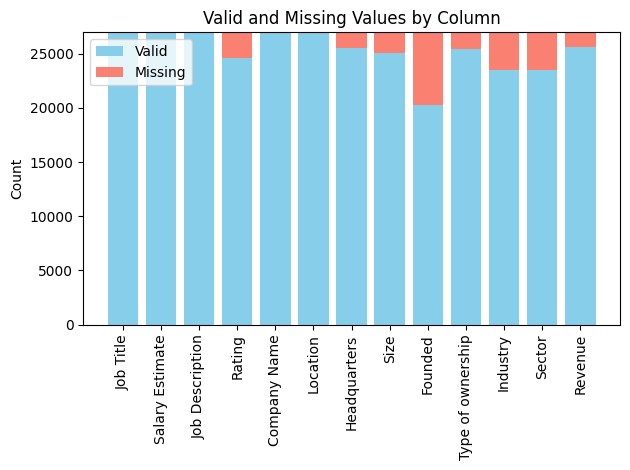

In [11]:
missing_counts = df.replace({-1: np.nan, '-1': np.nan,'Unknown': np.nan}).isnull().sum()
valid_counts = df.replace({-1: np.nan, '-1': np.nan,'Unknown': np.nan}).notnull().sum()
print(missing_counts)

categories = df.columns
x = range(len(categories))

plt.bar(x, valid_counts, label='Valid', color='skyblue')
plt.bar(x, missing_counts, bottom=valid_counts, label='Missing', color='salmon')
plt.xticks(x, categories, rotation=90)
plt.ylabel('Count')
plt.title('Valid and Missing Values by Column')
plt.legend()

plt.tight_layout()
plt.show()

# Exploratory Data Analysis: Target & Numerical Features

## Target Variable Analysis: Salary

In [12]:
unique_salaries = df['Salary Estimate'].nunique()
print(unique_salaries)

# print(df['Salary Estimate'].value_counts().head(10))
# print(df['Salary Estimate'].value_counts().tail(10))



819


In [13]:
per_hour = df['Salary Estimate'].str.contains('Per Hour', case=False, na=False)
per_hour_count = per_hour.sum()
per_year = df['Salary Estimate'].str.contains(r'\$\d+K-\$\d+K', case=False, na=False)
per_year_count = per_year.sum()
other_format = df[~(per_hour | per_year)]
print(f"per_hour_count: {per_hour_count}")
print(f"per_year_count: {per_year_count}")
# print(other_format['Salary Estimate'])
print(other_format.shape[0])


per_hour_count: 114
per_year_count: 26819
47


In [14]:
df = df[~per_hour]
df = df[df['Salary Estimate'] != '-1']


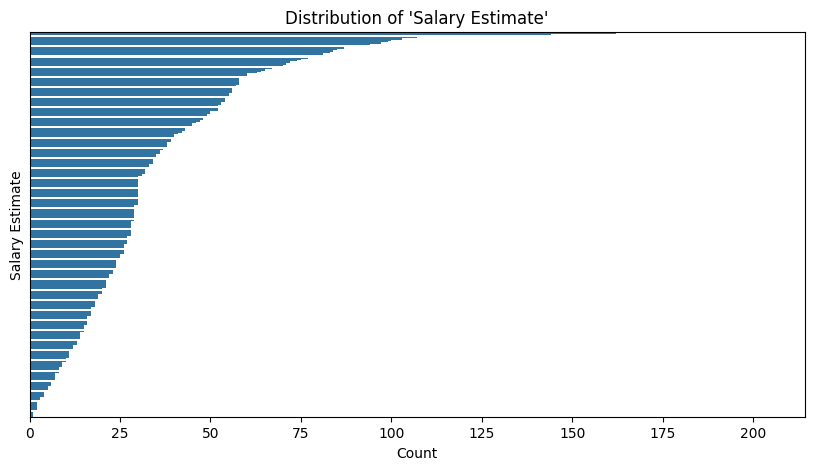

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(
    y=df['Salary Estimate'],
    order=df['Salary Estimate'].value_counts().index
)
plt.yticks([])
plt.title("Distribution of 'Salary Estimate'")
plt.xlabel("Count")
plt.ylabel("Salary Estimate")
plt.show()


In [16]:
# Salary Estimate to 2 columns: Salary Min and Salary Max
df['Salary Min'] = df['Salary Estimate'].str.extract(r'(\d+)K')[0].astype(float) * 1000
df['Salary Max'] = df['Salary Estimate'].str.extract(r'-\$(\d+)K')[0].astype(float) * 1000
print(df[['Salary Estimate', 'Salary Min', 'Salary Max']].head())


               Salary Estimate  Salary Min  Salary Max
0  $56K-$102K (Glassdoor est.)     56000.0    102000.0
1  $56K-$102K (Glassdoor est.)     56000.0    102000.0
2  $56K-$102K (Glassdoor est.)     56000.0    102000.0
3  $56K-$102K (Glassdoor est.)     56000.0    102000.0
4  $56K-$102K (Glassdoor est.)     56000.0    102000.0


In [17]:
# check if there's no not integer values
not_integer_min = df[~df['Salary Min'].apply(float.is_integer)]
not_integer_max = df[~df['Salary Max'].apply(float.is_integer)]

print(not_integer_min[['Salary Estimate', 'Salary Min']].head())
print(not_integer_max[['Salary Estimate', 'Salary Max']].head())


Empty DataFrame
Columns: [Salary Estimate, Salary Min]
Index: []
Empty DataFrame
Columns: [Salary Estimate, Salary Max]
Index: []


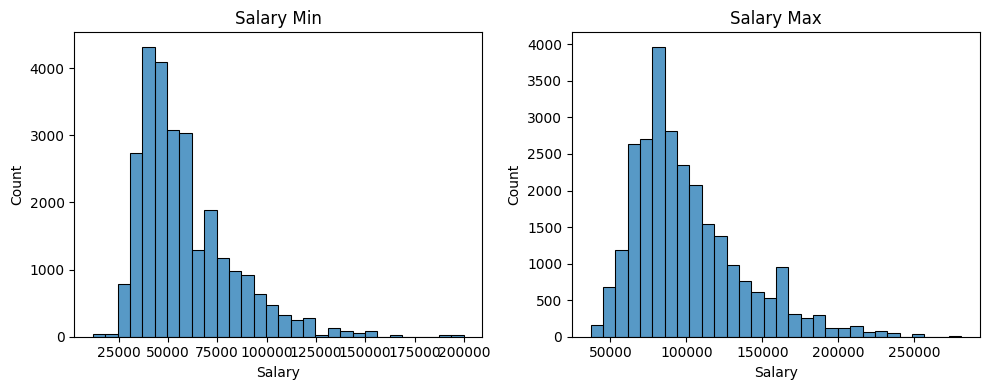

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['Salary Min'], bins=30, ax=axes[0])
axes[0].set_title("Salary Min")
axes[0].set_xlabel("Salary")
axes[0].set_ylabel("Count")

sns.histplot(df['Salary Max'], bins=30, ax=axes[1])
axes[1].set_title("Salary Max")
axes[1].set_xlabel("Salary")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [19]:
df['SalaryAvg'] = (df['Salary Min'] + df['Salary Max']) / 2

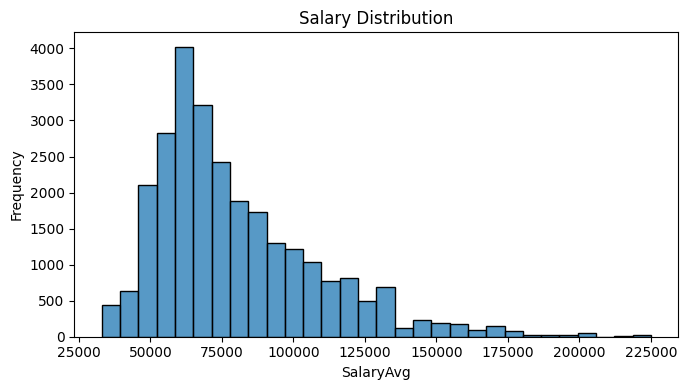

In [20]:
plt.figure(figsize=(7, 4))
sns.histplot(df['SalaryAvg'], bins=30)
plt.title('Salary Distribution')
plt.xlabel('SalaryAvg')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26819 entries, 0 to 26979
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          26819 non-null  object 
 1   Salary Estimate    26819 non-null  object 
 2   Job Description    26819 non-null  object 
 3   Rating             26819 non-null  float64
 4   Company Name       26819 non-null  object 
 5   Location           26819 non-null  object 
 6   Headquarters       26819 non-null  object 
 7   Size               26819 non-null  object 
 8   Founded            26819 non-null  int64  
 9   Type of ownership  26819 non-null  object 
 10  Industry           26819 non-null  object 
 11  Sector             26819 non-null  object 
 12  Revenue            26819 non-null  object 
 13  Salary Min         26819 non-null  float64
 14  Salary Max         26819 non-null  float64
 15  SalaryAvg          26819 non-null  float64
dtypes: float64(4), int64(1), ob

## Numerical Features Analysis

In [22]:
df.describe()

,Rating,Founded,Salary Min,Salary Max,SalaryAvg
count,26819.000000,26819.000000,26819.000000,26819.000000,26819.000000
mean,3.308367,1482.958947,58803.572094,100606.137440,79704.854767
std,1.470870,853.573244,23883.466818,35849.781378,28810.691955
min,-1.000000,-1.000000,12000.000000,37000.000000,33000.000000
25%,3.200000,1775.000000,42000.000000,76000.000000,60000.000000
50%,3.700000,1976.000000,52000.000000,91000.000000,71500.000000
75%,4.000000,2001.000000,71000.000000,118500.000000,93000.000000
max,5.000000,2020.000000,200000.000000,281000.000000,225000.000000


In [23]:
df.drop(['Salary Estimate', 'Salary Min', 'Salary Max'], axis=1, inplace=True)

In [24]:
df_filtered = df[df != -1].dropna()
df_filtered.describe()


,Rating,Founded,SalaryAvg
count,19981.000000,19981.000000,19981.000000
mean,3.735784,1972.281868,79722.961814
std,0.578335,50.428712,28973.916686
min,1.000000,1625.000000,33000.000000
25%,3.400000,1962.000000,60000.000000
50%,3.700000,1994.000000,71500.000000
75%,4.100000,2004.000000,93000.000000
max,5.000000,2020.000000,225000.000000


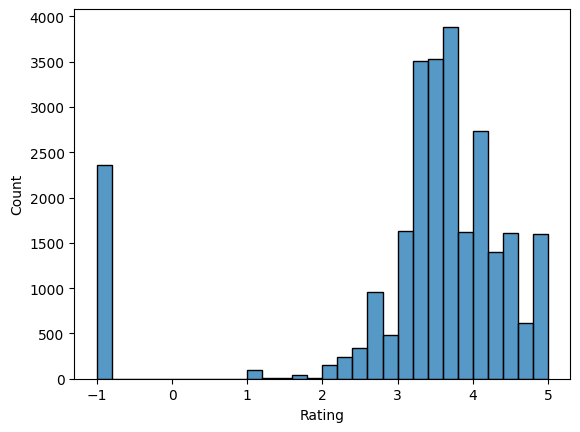

In [25]:
sns.histplot(df['Rating'], bins=30)
plt.xlabel('Rating')
plt.show()

In [26]:
df['Rating'] = df['Rating'].replace(-1, df[df['Rating'] != -1]['Rating'].mean())
df[['Rating']].describe()

,Rating
count,26819.000000
mean,3.723687
std,0.611590
min,1.000000
25%,3.400000
50%,3.723687
75%,4.000000
max,5.000000


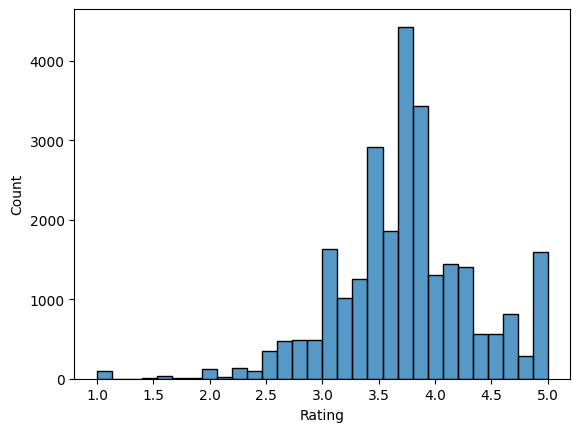

In [27]:
sns.histplot(df['Rating'], bins=30)
plt.xlabel('Rating')
plt.show()

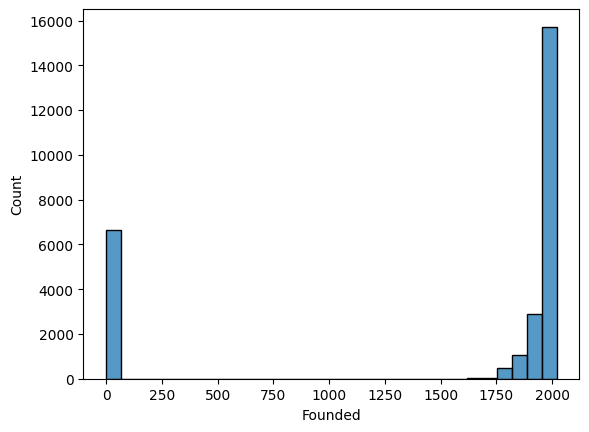

In [28]:
sns.histplot(df['Founded'], bins=30)
plt.xlabel('Founded')
plt.show()

In [29]:
# checking some of the oldest companies
df[(df['Founded'] < 1750) & (df['Founded'] > 0)].head(3)

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,SalaryAvg
42,Business Analyst,"Business Analyst Whippany, NJThe US Consumer B...",3.8,Barclays\n3.8,"Whippany, NJ","London, United Kingdom",10000+ employees,1690,Company - Public,Banks & Credit Unions,Finance,$10+ billion (USD),66500.0
82,AVP Markets Execution Business Analyst - Proje...,AVP Markets Execution Business Analyst - Proje...,3.8,Barclays Bank\n3.8,"New York, NY","London, United Kingdom",10000+ employees,1690,Company - Public,Banks & Credit Unions,Finance,$10+ billion (USD),120000.0
1822,Contactless Card Fraud Strategy Analyst,Contactless Fraud Strategy Sr. Analyst\nWilmin...,3.8,Barclays\n3.8,"Wilmington, DE","London, United Kingdom",10000+ employees,1690,Company - Public,Banks & Credit Unions,Finance,$10+ billion (USD),108500.0


In [30]:
filtered = df[df['Founded'] != -1]['Founded']
mode_founded = filtered.mode()
median_founded = filtered.median()
mean_founded = filtered.mean()
print(mode_founded)
print(median_founded)
print(mean_founded)


0    2008
Name: Founded, dtype: int64
1994.0
1972.6322836598065


            Founded
count  26819.000000
mean    1981.407286
std       46.243027
min     1625.000000
25%     1976.000000
50%     2001.000000
75%     2008.000000
max     2020.000000


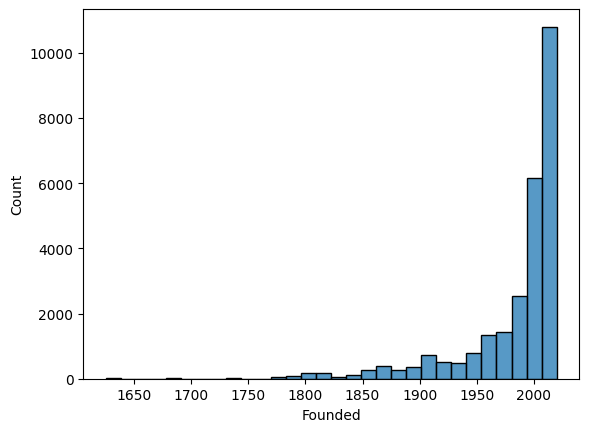

In [31]:
df['Founded'] = df['Founded'].replace(-1, df[df['Founded'] != -1]['Founded'].mode()[0])
print(df[['Founded']].describe())
sns.histplot(df['Founded'], bins=30)
plt.xlabel('Founded')
plt.show()

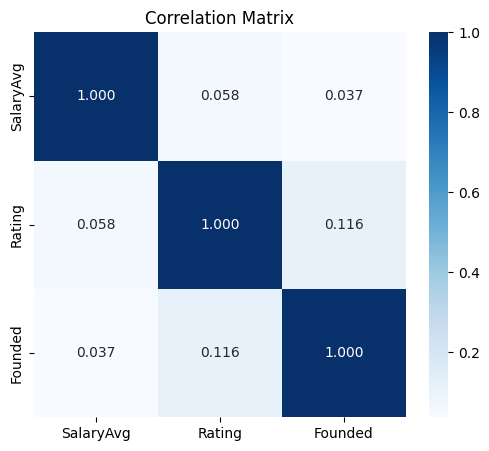

In [32]:
correlation_matrix = df[['SalaryAvg', 'Rating', 'Founded']].corr()
# print(correlation_matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.3f')
plt.title('Correlation Matrix')
plt.show()


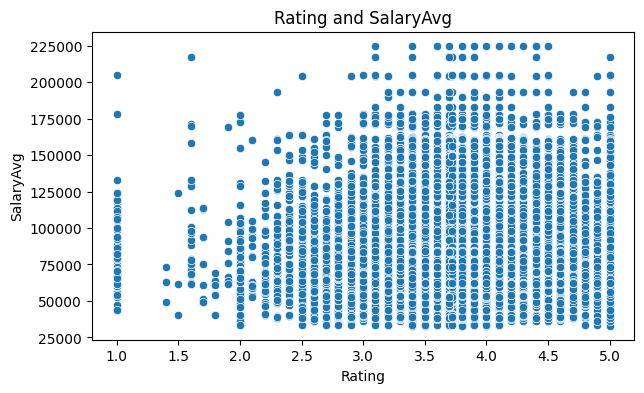

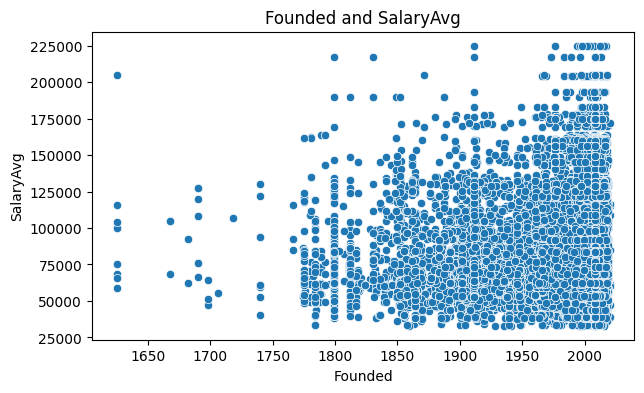

In [33]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Rating', y='SalaryAvg', data=df)
plt.title('Rating and SalaryAvg')
plt.show()

plt.figure(figsize=(7, 4))
sns.scatterplot(x='Founded', y='SalaryAvg', data=df)
plt.title('Founded and SalaryAvg')
plt.show()

In [34]:
df.drop('Founded', axis=1, inplace=True)

In [35]:
df.head(1)

,Job Title,Job Description,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg
0,Business Analyst - Clinical & Logistics Platform,Company Overview\n\n\nAt Memorial Sloan Ketter...,3.9,Memorial Sloan-Kettering\n3.9,"New York, NY","New York, NY",10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0


# Feature Engineering & Exploratory Data Analysis

### Job Category Extraction (Regex + LightGBM NLP Model) & Analysis
> Job titles are highly heterogeneous. We first apply Regex Rule-Based Matching to map titles to core categories (`Data Analyst`, `Business Analyst`, `Data Scientist`, etc.).
>
> For the remaining unclassified positions, we train an NLP Classifier (TF-IDF + LightGBM) using the job descriptions to predict the category.

### Rule-Based Categorization (Regex)

In [36]:
df['JobCategory'] = None
df['Job Title'] = df['Job Title'].str.lower()
# Data Analyst
df.loc[
    (df['Job Title'].str.contains(r'data', na=False, flags=re.IGNORECASE)) &
    (df['Job Title'].str.contains(r'analyst|analysis|analytics', na=False, flags=re.IGNORECASE)) &
    (~df['Job Title'].str.contains(r'engineer|engineering', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'Data Analyst'

# Business Analyst
df.loc[
    (df['Job Title'].str.contains(r'business', na=False, flags=re.IGNORECASE)) &
    (df['Job Title'].str.contains(r'analyst|analysis|intelligence|analytics', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'Business Analyst'

# Data Scientist
df.loc[
    (df['Job Title'].str.contains(r'data', na=False, flags=re.IGNORECASE)) &
    (df['Job Title'].str.contains(r'scientist|science', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'Data Scientist'

# Data Engineer
df.loc[
    (df['Job Title'].str.contains(r'data|BI', na=False, flags=re.IGNORECASE)) &
    (df['Job Title'].str.contains(r'engineer|developer|technician|architect|modeler', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'Data Engineer'

# Manager
df.loc[
    (df['Job Title'].str.contains(r'manager', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'Manager'

# Software Engineers
df.loc[
    (df['Job Title'].str.contains(r'software', na=False, flags=re.IGNORECASE)) &
    (df['Job Title'].str.contains(r'engineer|developer', na=False, flags=re.IGNORECASE)),
    # (~df['Job Title'].str.contains(r'[Dd]ata', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'Other Engineers'

# ML/AI Engineer
df.loc[
    (df['Job Title'].str.contains(r'machine learning|ml|artificial|ai', na=False, flags=re.IGNORECASE)) &
    (df['Job Title'].str.contains(r'engineer', na=False, flags=re.IGNORECASE)),
    # (~df['Job Title'].str.contains(r'[Dd]ata', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'ML/AI Engineer'

# Consultants
df.loc[
    (df['Job Title'].str.contains(r'consultant|consulting', na=False, flags=re.IGNORECASE)),
    'JobCategory'
] = 'Consultant'
print(df['JobCategory'].isna().sum())



8093


In [37]:
print(df[['Job Title', 'JobCategory']].head(10))

                                          Job Title       JobCategory
0  business analyst - clinical & logistics platform  Business Analyst
1                                  business analyst  Business Analyst
2                                      data analyst      Data Analyst
3   information security analyst, incident response              None
4                     analyst - fp&a global revenue              None
5                                      data analyst      Data Analyst
6                     investment analyst - graduate              None
7                      it business process analysis  Business Analyst
8                          tolling business analyst  Business Analyst
9                           business analyst - risk  Business Analyst


### NLP Pipeline (TF-IDF + LightGBM Classifier)

In [38]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[/,-]', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['Job Description'] = df['Job Description'].fillna('').apply(clean_text)
df.rename(columns={'Job Description': 'JobDescriptionCleaned'}, inplace=True)

labeled_data = df[df['JobCategory'].notna()].copy()
remaining_data = df[df['JobCategory'].isna()].copy()

labeled_data['JobText'] = (labeled_data['Job Title'] + " " + labeled_data['JobDescriptionCleaned'])
remaining_data['JobText'] = (remaining_data['Job Title'] + " " + remaining_data['JobDescriptionCleaned'])



In [39]:
label_encoder = LabelEncoder()
y_text = label_encoder.fit_transform(labeled_data['JobCategory'])
X_text_raw = labeled_data['JobText']

In [40]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(X_text_raw, y_text, test_size=0.2, random_state=40)

In [41]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)
X_remaining_tfidf = vectorizer.transform(remaining_data['JobText'])

In [42]:
# LGBMClassifier for classification of remaining data
model = lgb.LGBMClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=6,
    class_weight='balanced',
    verbosity=-1
)
model.fit(X_train_tfidf, y_train_text)
y_pred_text = model.predict(X_test_tfidf)
print(classification_report(y_test_text, y_pred_text, target_names=label_encoder.classes_))


                  precision    recall  f1-score   support

Business Analyst       0.94      0.92      0.93      1379
      Consultant       0.93      0.97      0.95       226
    Data Analyst       0.92      0.92      0.92      1310
   Data Engineer       0.89      0.89      0.89       384
  Data Scientist       0.90      0.95      0.92       217
  ML/AI Engineer       0.84      0.70      0.76        37
         Manager       0.79      0.85      0.82       109
 Other Engineers       0.82      0.90      0.86        84

        accuracy                           0.92      3746
       macro avg       0.88      0.89      0.88      3746
    weighted avg       0.92      0.92      0.92      3746



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


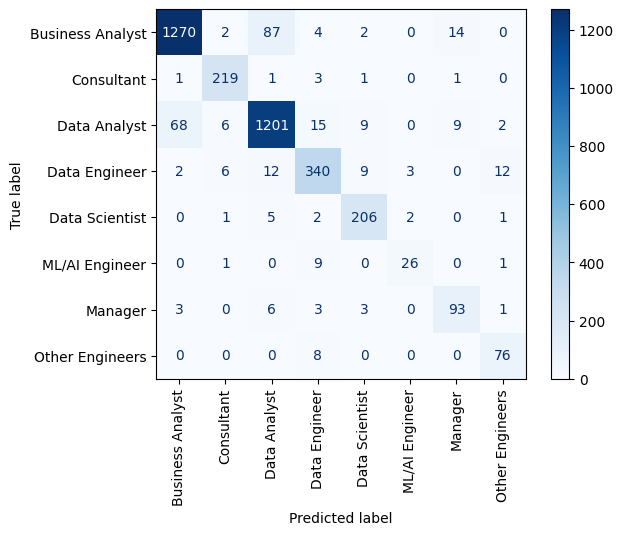

In [43]:
cm = confusion_matrix(y_test_text, y_pred_text, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.show()


In [44]:
remaining_data['PredictedCategory'] = label_encoder.inverse_transform(model.predict(X_remaining_tfidf))
df.loc[df['JobCategory'].isna(), 'JobCategory'] = remaining_data['PredictedCategory']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
print(df[['Job Title', 'JobCategory']].head(10))

                                          Job Title       JobCategory
0  business analyst - clinical & logistics platform  Business Analyst
1                                  business analyst  Business Analyst
2                                      data analyst      Data Analyst
3   information security analyst, incident response  Business Analyst
4                     analyst - fp&a global revenue  Business Analyst
5                                      data analyst      Data Analyst
6                     investment analyst - graduate           Manager
7                      it business process analysis  Business Analyst
8                          tolling business analyst  Business Analyst
9                           business analyst - risk  Business Analyst


### Job Category EDA

In [46]:
categories = df['JobCategory'].unique()
palette = sns.color_palette('hls', len(categories))
palette_dict = {category: palette[i] for i, category in enumerate(categories)}

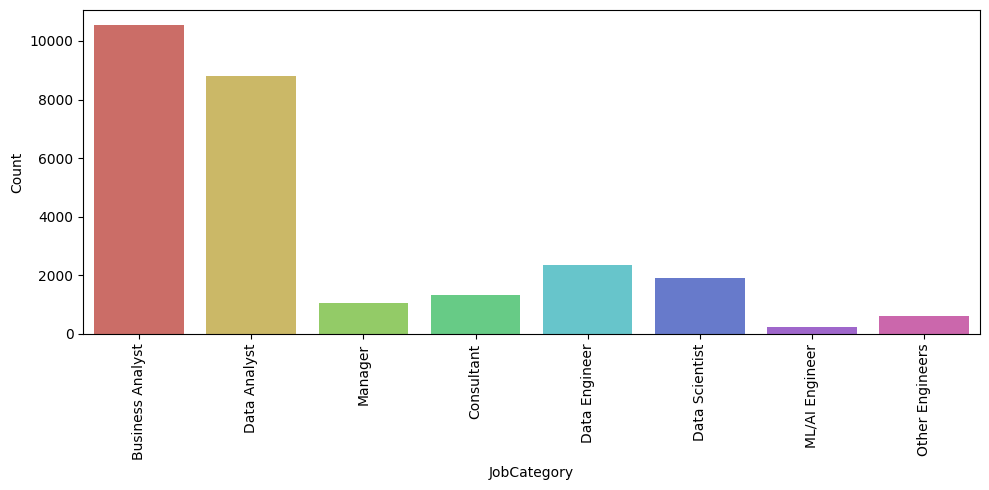

In [47]:
plt.figure(figsize=(10, 5))
sns.countplot(x='JobCategory', data=df, hue = 'JobCategory', legend = False, palette=palette_dict)
plt.xticks(rotation=90)
plt.xlabel('JobCategory')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

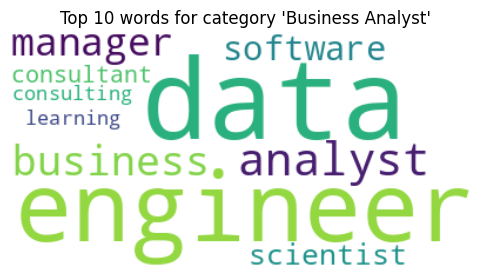

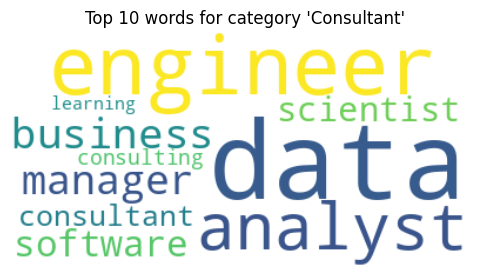

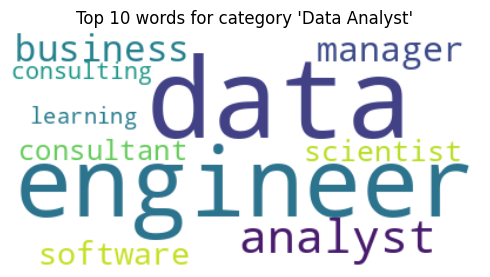

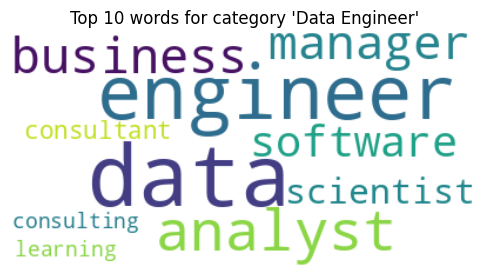

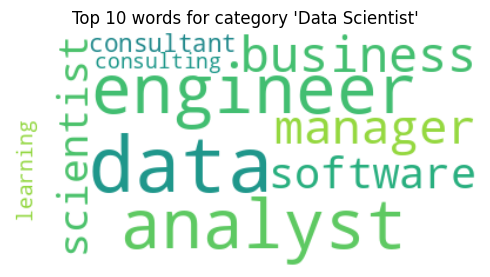

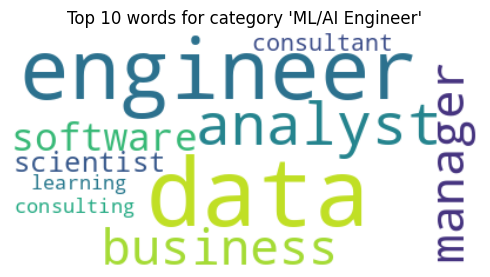

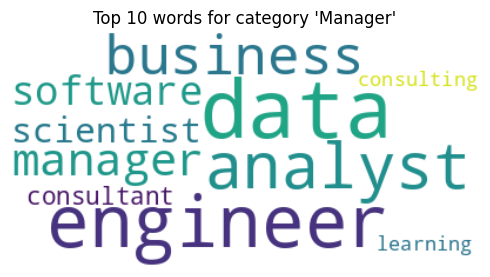

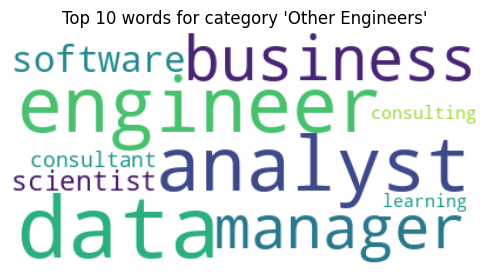

In [48]:
feature_names = np.array(vectorizer.get_feature_names_out())
feature_importances = model.feature_importances_
categories = model.classes_
top_n = 10

for i, category in enumerate(categories):
    category = label_encoder.inverse_transform([category])[0]
    # print(f"Top {top_n} words for category '{category}':")
    top_indices = np.argsort(feature_importances)[-top_n:][::-1]
    top_words = feature_names[top_indices]
    top_weights = feature_importances[top_indices]
    # for word, weight in zip(top_words, top_weights):
    #     print(f"{word}: {weight:.4f}")
    print()

    word_freq = {word: weight for word, weight in zip(top_words, top_weights)}
    wordcloud = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(word_freq)
    plt.figure(figsize=(5, 3))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {top_n} words for category '{category}'")
    plt.tight_layout()
    plt.show()


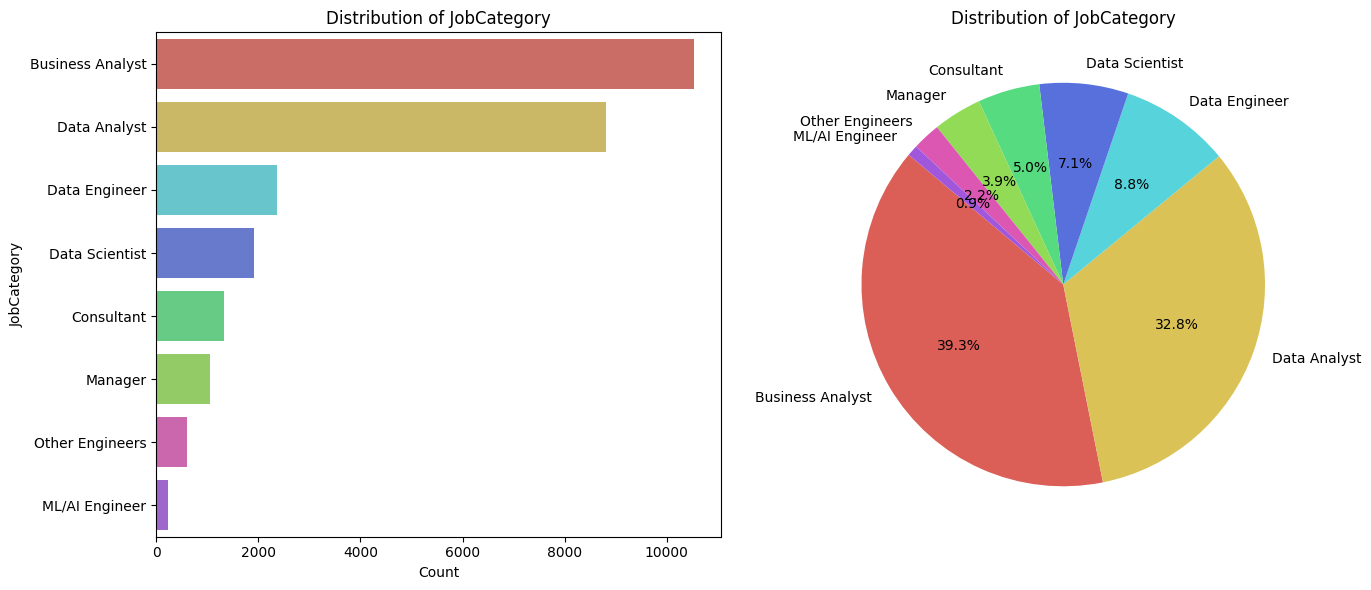

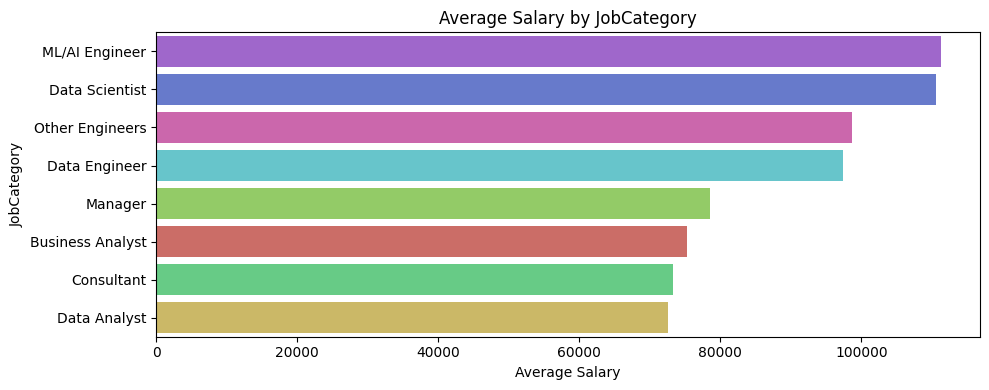

In [49]:
# JobCategory Statistics

category_counts = df['JobCategory'].value_counts()

total_count = category_counts.sum()
threshold = 0.01 * total_count

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=category_counts.index, x=category_counts.values, hue=category_counts.index, legend=False,
            palette=palette_dict)
plt.title('Distribution of JobCategory')
plt.xlabel('Count')
plt.ylabel('JobCategory')

plt.subplot(1, 2, 2)
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict.get(category, 'gray') for category in category_counts.index])
plt.title('Distribution of JobCategory')

plt.tight_layout()
plt.show()

category_salary_avg = df.groupby('JobCategory')['SalaryAvg'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(y=category_salary_avg.index, x=category_salary_avg.values, hue=category_salary_avg.index, legend=False, palette=palette_dict)
plt.xlabel('Average Salary')
plt.ylabel('JobCategory')
plt.title('Average Salary by JobCategory')
plt.tight_layout()
plt.show()


In [50]:
df.head(1)

,Job Title,JobDescriptionCleaned,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory
0,business analyst - clinical & logistics platform,company overview\n\n\nat memorial sloan ketter...,3.9,Memorial Sloan-Kettering\n3.9,"New York, NY","New York, NY",10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0,Business Analyst


## Tech Skills

In [51]:
skill_variants = {
    'Python': ['python'],
    'SQL': ['sql', 'structured query language'],
    'NoSQL': ['nosql', 'non relational databases', 'no sql'],
    'Excel': ['excel'],
    'Math': ['linear algebra', 'math'],
    'Statistics':['statistics'],
    'PowerBI':['powerbi', 'power bi'],
    'Tableau':['tableau'],
    'Java': ['java'],
    'JavaScript': ['javascript', 'js'],
'ETL': ['etl', 'extract transform load'],
'Spark': ['spark', 'apache spark'],
'Hadoop': ['hadoop'],
'Teamwork': ['teamwork', 'collaboration'],
'Leadership': ['leadership', 'team management'],
    'API Development': ['api']
}

skills_df = pd.DataFrame(index=df.index)

for skill, variants in skill_variants.items():
    # Create a regex pattern like r'\b(sql|structured query language)\b'
    pattern = r'\b(?:' + '|'.join(map(re.escape, variants)) + r')\b'
    skills_df[skill] = df['JobDescriptionCleaned'].str.contains(pattern, flags=re.IGNORECASE, regex=True, na=False).astype(int)

categories = pd.get_dummies(df['JobCategory'])
skill_category_matrix = categories.T.dot(skills_df)

print(skill_category_matrix)
print(skill_category_matrix.shape)




                 Python   SQL NoSQL Excel Math Statistics PowerBI Tableau  \
Business Analyst    603  2825    53  3555  266        559     473     992   
Consultant          114   243    27   361   35        126      53      67   
Data Analyst       1840  4332   156  3997  422       2008     924    1924   
Data Engineer      1275  1244   399   230   77        251     164     348   
Data Scientist     1045   716    78   226  207        889      83     244   
ML/AI Engineer      159    68    26    19   16         45       5       9   
Manager              91   208     4   370   44        112      40      88   
Other Engineers     244   199    72    34   28         18       9      14   

                 Java JavaScript   ETL Spark Hadoop Teamwork Leadership  \
Business Analyst  388        208   362    59     86     1443       2087   
Consultant         93         32    45    32     24      247        458   
Data Analyst      339        511  1098   183    301     1250       1762   
Data E

In [52]:
skill_category_long = (
    skill_category_matrix.reset_index()
    .melt(id_vars='index', var_name='skill', value_name='frequency')
    .query('frequency > 0')
    .rename(columns={'index': 'jobcategory'})
)


In [53]:
from ipywidgets import interact

def interactive_plot_skill_distribution(category):
    category_data = skill_category_long[skill_category_long['jobcategory'] == category]

    plt.figure(figsize=(10, 4))
    sns.barplot(
        x='frequency',
        y='skill',
        data=category_data,
        palette='hls', hue = 'skill', legend = False
    )
    plt.title(f'Frequency of Skills in Job Descriptions - {category}')
    plt.xlabel('Frequency')
    plt.ylabel('Skill')
    plt.tight_layout()
    plt.show()

interact(
    interactive_plot_skill_distribution,
    category=skill_category_long['jobcategory'].unique()
)
None

interactive(children=(Dropdown(description='category', options=('Business Analyst', 'Consultant', 'Data Analys…

/tmp/ipykernel_1456/1594036049.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  relative_skill_category = skill_category_matrix.div(category_totals, axis=0).fillna(0)


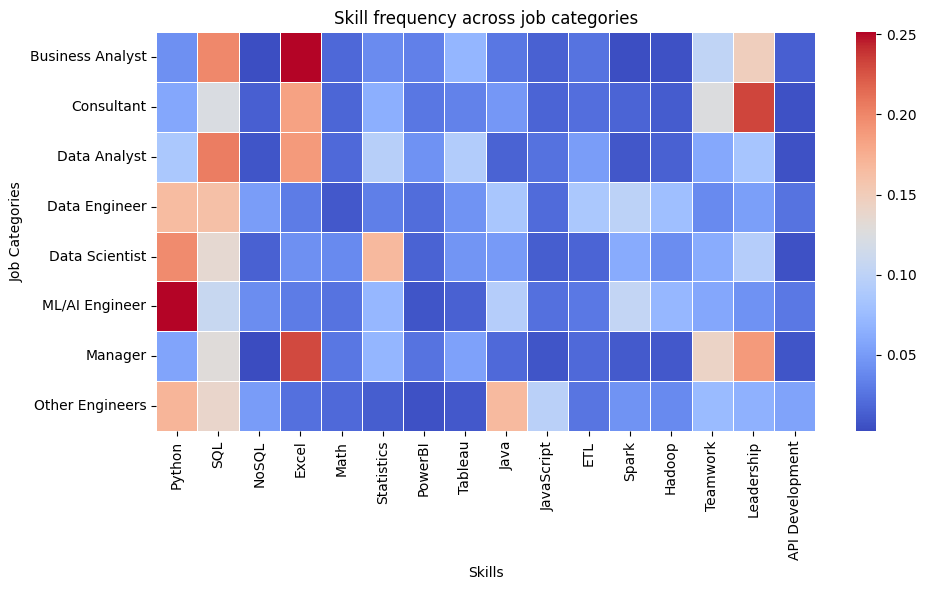

In [54]:
category_totals = skill_category_matrix.sum(axis=1)
relative_skill_category = skill_category_matrix.div(category_totals, axis=0).fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(
    relative_skill_category,
    annot=False,
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5
)
plt.title('Skill frequency across job categories')
plt.xlabel('Skills')
plt.ylabel('Job Categories')
plt.tight_layout()
plt.show()


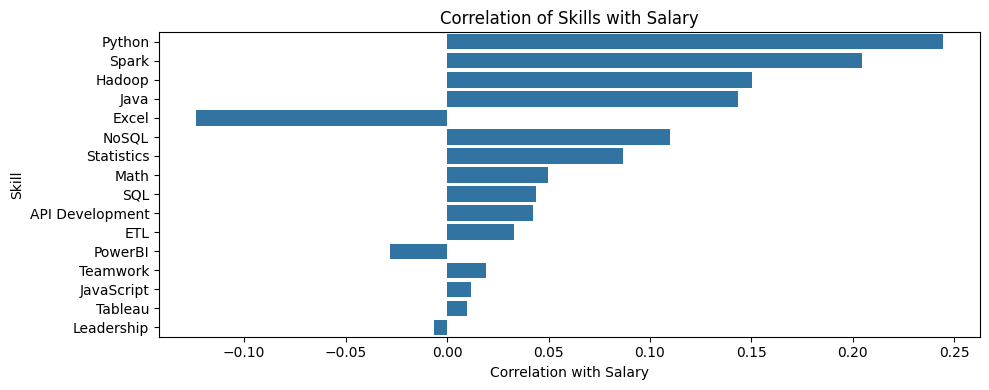

In [55]:
salary_column = df['SalaryAvg'].values

skill_salary_correlation = []

for skill in skills_df.columns:
    skill_values = skills_df[skill].values
    if len(np.unique(skill_values)) > 1:
        correlation, _ = pearsonr(skill_values, salary_column)
    else:
        correlation = np.nan
    skill_salary_correlation.append(correlation)

correlation_df = pd.DataFrame({
    'Skill': skills_df.columns,
    'SalaryCorrelation': skill_salary_correlation
})

correlation_df = correlation_df.dropna().sort_values(by='SalaryCorrelation', key=np.abs, ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x='SalaryCorrelation', y='Skill', data=correlation_df)
plt.title('Correlation of Skills with Salary')
plt.xlabel('Correlation with Salary')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()



In [56]:
skills_correlated = correlation_df[correlation_df['SalaryCorrelation'].abs() > 0.2]
selected_skills = skills_correlated['Skill'].values
print(selected_skills)

for skill in selected_skills:
    df[skill] = skills_df[skill]
df.head(1)

['Python' 'Spark']


,Job Title,JobDescriptionCleaned,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory,Python,Spark
0,business analyst - clinical & logistics platform,company overview\n\n\nat memorial sloan ketter...,3.9,Memorial Sloan-Kettering\n3.9,"New York, NY","New York, NY",10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0,Business Analyst,0,0


## Experience Level

In [57]:
def extract_experience_level(row):
    text = row['Job Title'] + " " + row['JobDescriptionCleaned']
    if re.search(r'\b(intern|trainee|internship)\b', text, re.IGNORECASE):
        return 'Intern/Trainee'
    elif re.search(r'\b(junior|entry level)\b', text, re.IGNORECASE):
        return 'Junior'
    elif re.search(r'\b(middle|mid level|midlevel)\b', text, re.IGNORECASE):
        return 'Middle'
    elif re.search(r'\b(senior|lead|principal)\b', text, re.IGNORECASE):
        return 'Senior'
    else:
        return 'Unknown'

df['ExperienceLevel'] = df.apply(extract_experience_level, axis=1)

# print(df[['Job Title', 'JobDescriptionCleaned', 'ExperienceLevel']].head(10))

experience_counts = df['ExperienceLevel'].value_counts()

print("experience_counts")
print(experience_counts)


experience_counts
ExperienceLevel
Unknown           13698
Senior            10273
Junior             1991
Middle              456
Intern/Trainee      401
Name: count, dtype: int64


In [58]:
filtered_df = df[
    df['JobDescriptionCleaned'].str.contains(r'\bper hour\b', case=False, na=False)
    # &  ~df['Job Description'].str.contains(r'\bpaid\b' , case=False, na=False)
]
count = len(filtered_df)
print(f"per hour: {count}")

experience_level_counts = filtered_df['ExperienceLevel'].value_counts()
print(experience_level_counts)

filtered_df = df[
    (df['ExperienceLevel'] == 'Intern/Trainee') &
    df['JobDescriptionCleaned'].str.contains(r'\bunpaid\b', case=False, na=False)
      &  ~df['JobDescriptionCleaned'].str.contains(r'\bpaid\b' , case=False, na=False)
]
count = len(filtered_df)
print(f"unpaid: {count}")

# filtered_df[['Job Description', 'ExperienceLevel', 'SalaryAvg']]

per hour: 422
ExperienceLevel
Unknown           278
Senior            101
Junior             29
Intern/Trainee     10
Middle              4
Name: count, dtype: int64
unpaid: 8


In [59]:
# Removing rows where 'JobDescriptionCleaned' contains "per hour"
condition = (
    df['JobDescriptionCleaned'].str.contains(r'\bper hour\b', case=False, na=False)
)

df = df[~condition]

print(df.shape)

(26397, 16)


In [60]:
# Removing rows where 'JobDescriptionCleaned' contains "unpaid" for trainees (as in the case of other experience levels, these terms usually appear in a different context)
condition = (
    (df['ExperienceLevel'] == 'Intern/Trainee') &
    df['JobDescriptionCleaned'].str.contains(r'\bunpaid\b', case=False, na=False) &
    ~df['JobDescriptionCleaned'].str.contains(r'\bpaid\b', case=False, na=False)
)

df = df[~condition]

print(df.shape)


(26389, 16)


In [61]:
paired_colors = plt.cm.Paired.colors
experience_colors = {
    'Intern/Trainee': 'plum',
    'Junior': 'yellowgreen',
    'Middle': 'sandybrown',
    'Senior': 'cornflowerblue',
    'Unknown': 'gray'
}

ExperienceLevel   Intern/Trainee  Junior  Middle  Senior  Unknown
JobCategory                                                      
Business Analyst             130     774     210    4105     5109
Consultant                    55     135      32     659      439
Data Analyst                 116     665     122    3090     4661
Data Engineer                 27     143      20     817     1323
Data Scientist                42     141      31     773      910
ML/AI Engineer                 1       5       3      65      160
Manager                        5      42      23     483      475
Other Engineers                7      57      11     180      343


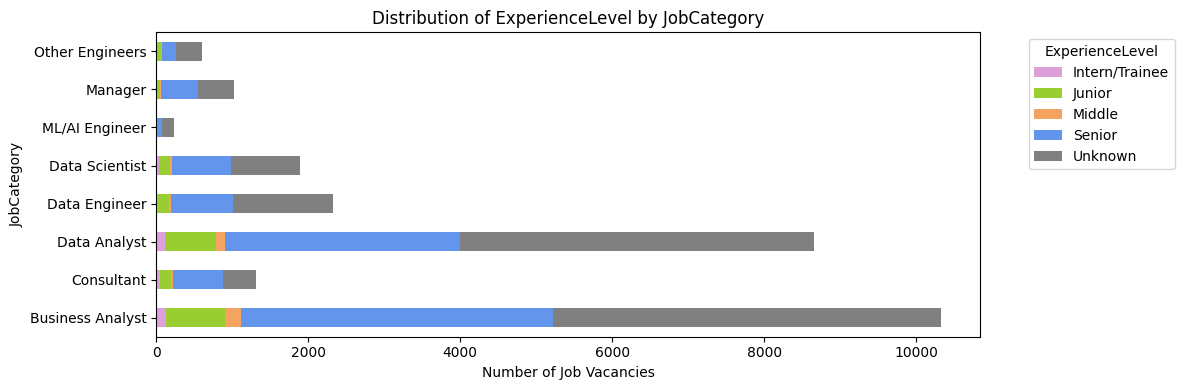

In [62]:
category_level_distribution = df.groupby(['JobCategory', 'ExperienceLevel']).size().unstack(fill_value=0)
print(category_level_distribution)

category_level_distribution.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 4),
    color=[experience_colors.get(level, 'gray') for level in category_level_distribution.columns]
)

plt.title("Distribution of ExperienceLevel by JobCategory")
plt.xlabel("Number of Job Vacancies")
plt.ylabel("JobCategory")
plt.legend(title="ExperienceLevel", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



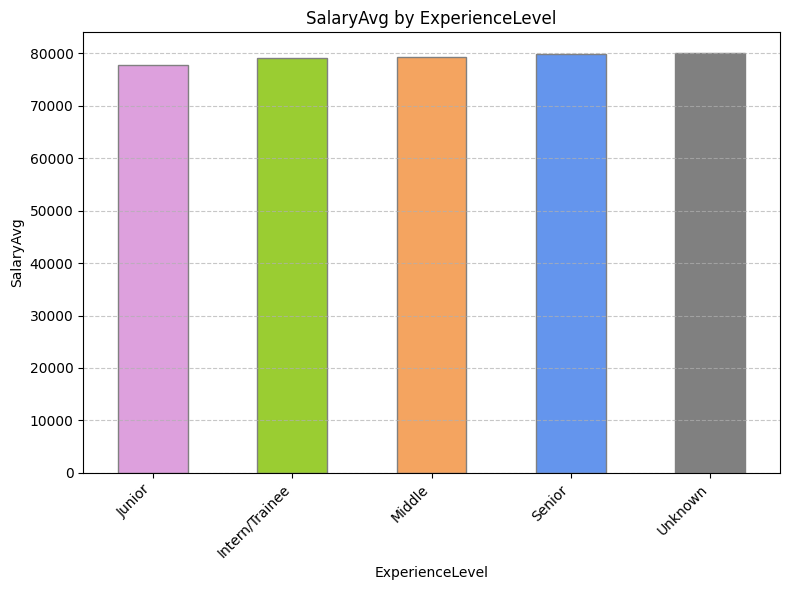

In [63]:
average_salary_by_level = df.groupby('ExperienceLevel')['SalaryAvg'].mean().sort_values()

colors = average_salary_by_level.index.map(lambda x: 'gray' if x == 'Unknown' else 'skyblue')

plt.figure(figsize=(8, 6))
average_salary_by_level.plot(kind='bar', color=[experience_colors.get(level, 'gray') for level in category_level_distribution.columns], edgecolor='gray' )
plt.title("SalaryAvg by ExperienceLevel")
plt.xlabel("ExperienceLevel")
plt.ylabel("SalaryAvg")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


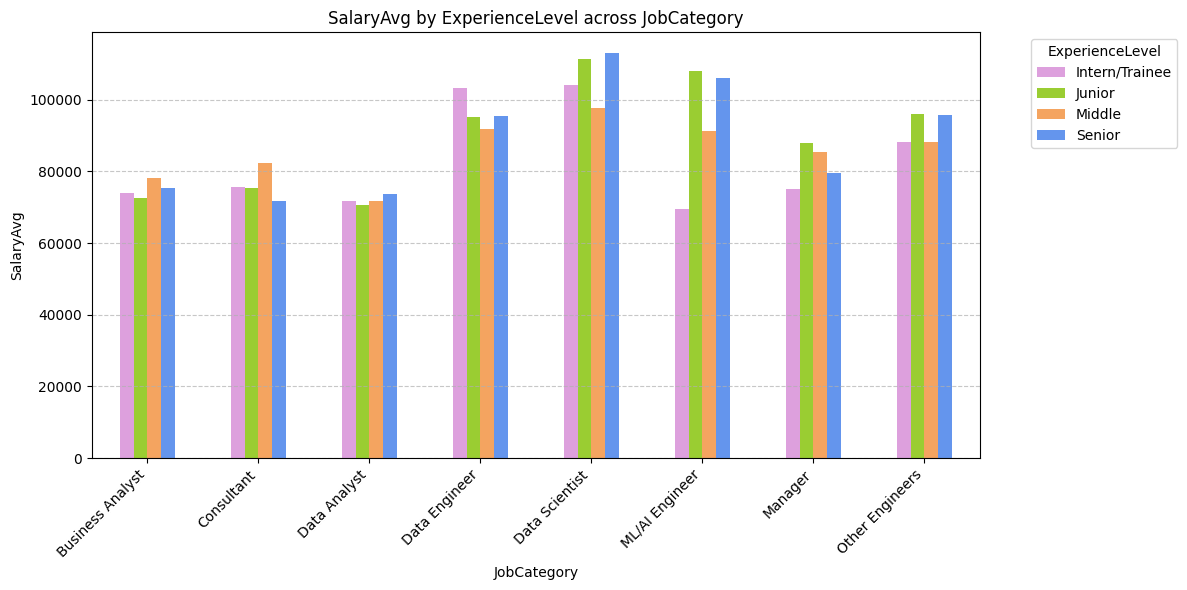

In [64]:

average_salary_by_category_level = df.groupby(['JobCategory', 'ExperienceLevel'])['SalaryAvg'].mean().unstack()

average_salary_by_category_level = average_salary_by_category_level.drop(columns='Unknown', errors='ignore')

average_salary_by_category_level.plot(kind='bar', figsize=(10, 6), color=[experience_colors.get(level, 'gray') for level in category_level_distribution.columns])

plt.title("SalaryAvg by ExperienceLevel across JobCategory")
plt.xlabel("JobCategory")
plt.ylabel("SalaryAvg")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend(title="ExperienceLevel", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [65]:
filtered_df = df[(df['JobCategory'] == 'Business Analyst') & (df['ExperienceLevel'] == 'Intern/Trainee')]
top_5_highest_salaries = filtered_df.nlargest(5, 'SalaryAvg')
top_5_highest_salaries

,Job Title,JobDescriptionCleaned,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory,Python,Spark,ExperienceLevel
1903,business analyst trainee,job description\nrole junior business analyst\...,5.0,"Staffigo Technical Services, LLC\n5.0","Philadelphia, PA","Woodridge, IL",51 to 200 employees,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),163500.0,Business Analyst,0,0,Intern/Trainee
19993,business analyst trainee,job description role junior business analyst ...,5.0,"Staffigo Technical Services, LLC\n5.0","Philadelphia, PA","Woodridge, IL",51 to 200 employees,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),163500.0,Business Analyst,0,0,Intern/Trainee
4905,community development finance analyst,community development finance analyst\n\napply...,3.0,Union Bank\n3.0,"Los Angeles, CA","San Francisco, CA",5001 to 10000 employees,Subsidiary or Business Segment,Banks & Credit Unions,Finance,$10+ billion (USD),135000.0,Business Analyst,0,0,Intern/Trainee
22560,community development finance analyst,community development finance analyst apply n...,3.0,Union Bank\n3.0,"Los Angeles, CA","San Francisco, CA",5001 to 10000 employees,Subsidiary or Business Segment,Banks & Credit Unions,Finance,$10+ billion (USD),135000.0,Business Analyst,0,0,Intern/Trainee
1824,it analyst co-op (intern),job descriptionas an it analyst intern you wil...,3.7,Radian Group Inc.\n3.7,"Philadelphia, PA","Philadelphia, PA",1001 to 5000 employees,Company - Public,Insurance Carriers,Insurance,$1 to $2 billion (USD),108500.0,Business Analyst,0,0,Intern/Trainee


In [66]:
df.head(1)

,Job Title,JobDescriptionCleaned,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory,Python,Spark,ExperienceLevel
0,business analyst - clinical & logistics platform,company overview\n\n\nat memorial sloan ketter...,3.9,Memorial Sloan-Kettering\n3.9,"New York, NY","New York, NY",10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0,Business Analyst,0,0,Unknown


## Education (Degree)

In [67]:
experience_keywords = {
    'Bachelor': r'\bbachelor\'?s\b|\bb\.s\.|\bb\.a\b|\bbachelors\b|\bbs\b|\bbachelor\b',
    'Master': r'\bmaster\'?s\b|\bms\b|\bmasters\b|\bm\.s\.|\bmaster\b|\badvanced\b',
    'PhD': r'\bph\.?\s?d\b|\bphd\b|\bph\.?\s?d\b'

}

def determine_degree(description):
    for level, pattern in experience_keywords.items():
        if pd.notna(description) and re.search(pattern, description):
            return level
    return 'Unknown'

df['Degree'] = df['JobDescriptionCleaned'].apply(determine_degree)

degree_counts = df['Degree'].value_counts()

for level, count in degree_counts.items():
    print(f"{level}: {count}")

Bachelor: 15244
Unknown: 6528
Master: 4439
PhD: 178


In [68]:
category_degree_distribution = df.groupby(['JobCategory', 'Degree']).size().unstack(fill_value=0)

print(category_degree_distribution)

Degree            Bachelor  Master  PhD  Unknown
JobCategory                                     
Business Analyst      6133    1477    0     2718
Consultant             880     125    2      313
Data Analyst          5130    1526   21     1977
Data Engineer         1119     366   10      835
Data Scientist         834     676  130      257
ML/AI Engineer         102      66    1       65
Manager                662     137    9      220
Other Engineers        384      66    5      143


In [69]:
paired_colors = plt.colormaps.get_cmap('tab20').colors
experience_colors = {
    'Bachelor': paired_colors[0],
    'Master': paired_colors[8],
    'PhD': paired_colors[12],
    'Unknown': paired_colors[15],
}

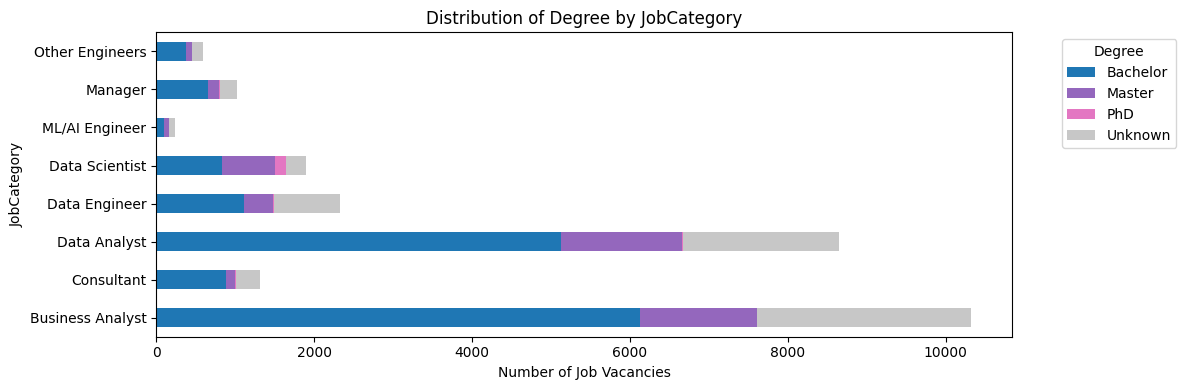

In [70]:
category_degree_distribution.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 4),
    color=[experience_colors.get(d) for d in category_degree_distribution.columns]
)

plt.title("Distribution of Degree by JobCategory")
plt.xlabel("Number of Job Vacancies")
plt.ylabel("JobCategory")
plt.legend(title="Degree", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


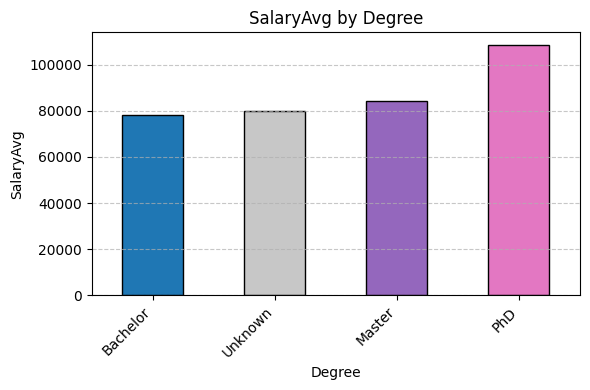

In [71]:
average_salary_by_degree = df.groupby('Degree')['SalaryAvg'].mean().sort_values()

plt.figure(figsize=(6, 4))
average_salary_by_degree.plot(kind='bar', color=[experience_colors.get(degree, 'gray') for degree in average_salary_by_degree.index], edgecolor='black')

plt.title("SalaryAvg by Degree")
plt.xlabel("Degree")
plt.ylabel("SalaryAvg")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [72]:
df.head(1)

,Job Title,JobDescriptionCleaned,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory,Python,Spark,ExperienceLevel,Degree
0,business analyst - clinical & logistics platform,company overview\n\n\nat memorial sloan ketter...,3.9,Memorial Sloan-Kettering\n3.9,"New York, NY","New York, NY",10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0,Business Analyst,0,0,Unknown,Bachelor


## Company Name

In [73]:
print(df['Company Name'].unique())
df['Company Name'] = df['Company Name'].apply(lambda x: re.sub(r'\n?\d+\.\d+$', '', x))
df['Company Name'] = df['Company Name'].str.lower()
print(df['Company Name'].unique())


['Memorial Sloan-Kettering\n3.9' 'Paine Schwartz Partners\n3.8'
 'Asembia\n3.6' ... 'Huntington Bancshares Inc\n3.5' 'DATAECONOMY\n5.0'
 'Data Resource Technologies\n4.0']
['memorial sloan-kettering' 'paine schwartz partners' 'asembia' ...
 'huntington bancshares inc' 'dataeconomy' 'data resource technologies']


In [74]:
df['Company Name'] = df['Company Name'].replace(['-1'], 'Unknown')
unique_feature = df['Company Name'].nunique()
print(unique_feature)
# print(df['Company Name'].value_counts().head())
print(df['Company Name'].isin(['Unknown']).sum())
# print(df['Company Name'].value_counts().tail())

7635
0


In [75]:
categories = df['Company Name'].unique()
palette = sns.color_palette('hls', len(categories))
palette_dict = {category: palette[i] for i, category in enumerate(categories)}

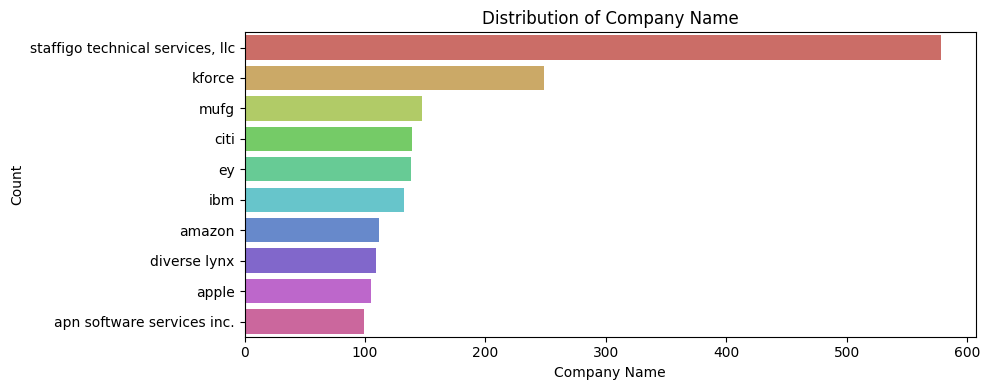

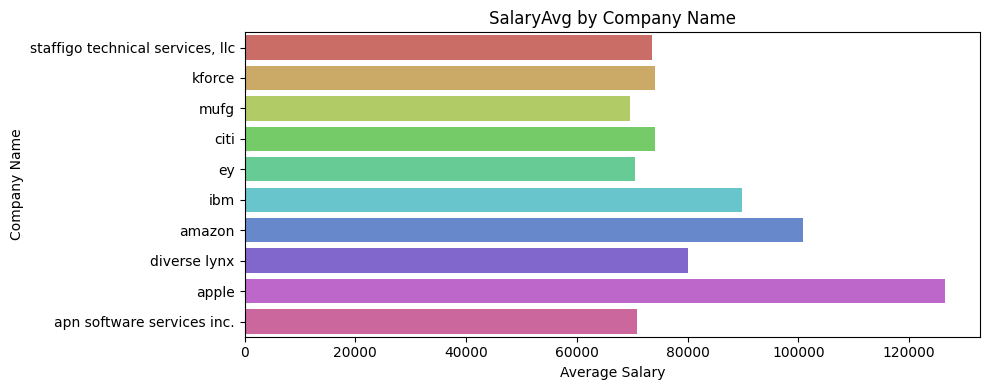

In [76]:
filtered_category = df[df['Company Name'] != 'Unknown']

company_counts = filtered_category['Company Name'].value_counts()

top_company_count = company_counts.head(10)
categories = top_company_count.index
palette = sns.color_palette('hls', len(categories))
palette_dict = {category: palette[i] for i, category in enumerate(categories)}

plt.figure(figsize=(10, 4))
sns.barplot(y=top_company_count.index, x=top_company_count.values, hue=top_company_count.index, legend=False, palette=palette_dict)
plt.title('Distribution of Company Name')
plt.xlabel('Company Name')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

category_salary_avg = filtered_category.groupby('Company Name')['SalaryAvg'].mean()

top_salary_avg = category_salary_avg.loc[top_company_count.index]

plt.figure(figsize=(10, 4))
sns.barplot(y=top_salary_avg.index, x=top_salary_avg.values, hue=top_salary_avg.index, legend=False, palette=palette_dict)
plt.xlabel('Average Salary')
plt.ylabel('Company Name')
plt.title('SalaryAvg by Company Name')
plt.tight_layout()
plt.show()


## Location

In [77]:
unique_feature = df['Location'].nunique()
print(unique_feature)
print(df['Location'].value_counts().head(10))

871
Location
New York, NY        2090
Houston, TX         1874
Chicago, IL         1866
Austin, TX          1550
San Diego, CA       1397
Los Angeles, CA     1264
Phoenix, AZ         1124
Dallas, TX           953
Jacksonville, FL     941
San Antonio, TX      861
Name: count, dtype: int64


In [78]:
def extract_city_state(location):
    parts = location.split(',')

    if len(parts) == 2:
        city, state = parts[0].strip(), parts[1].strip()
        if len(state) == 2:
            return city, state
        else:
            return city, "Unknown"

    elif len(parts) == 3:
        city = parts[0].strip()
        state = parts[2].strip()
        return city, state

    else:
        city = parts[0].strip()
        state = "Unknown"
        return city, state

df[['City', 'State']] = df['Location'].apply(lambda x: pd.Series(extract_city_state(x)))
df = df.drop(columns=['Location'])
df.head(1)

,Job Title,JobDescriptionCleaned,Rating,Company Name,Headquarters,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory,Python,Spark,ExperienceLevel,Degree,City,State
0,business analyst - clinical & logistics platform,company overview\n\n\nat memorial sloan ketter...,3.9,memorial sloan-kettering,"New York, NY",10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0,Business Analyst,0,0,Unknown,Bachelor,New York,NY


In [79]:
unique_feature = df['City'].nunique()
print(unique_feature)
unique_feature = df['State'].nunique()
print(unique_feature)

833
39


In [80]:
df['State'].isnull().sum()

np.int64(0)

In [81]:
df[df['State'] == 'Unknown'][['State', 'City']]

,State,City
14330,Unknown,Remote
14331,Unknown,Canada
14332,Unknown,United States
14333,Unknown,Remote
14334,Unknown,Remote
...,...,...
16014,Unknown,United States
25552,Unknown,Stevenage
25632,Unknown,Stevenage
25644,Unknown,Brentford


In [82]:
valid_cities = ['us', 'usa', 'united states']
valid_cities += df[df['State'] != 'Unknown']['City'].str.lower().unique().tolist()
print(valid_cities)
def clean_city_state(row):
    if row['State'] == 'Unknown':
        if row['City'].lower() in valid_cities:
            row['City'] = 'Unknown'
        else:
            return None
    return row

df = df.apply(clean_city_state, axis=1).dropna(subset=['City', 'State'])

['us', 'usa', 'united states', 'new york', 'florham park', 'franklin lakes', 'lyndhurst', 'jersey city', 'newark', 'brooklyn', 'hackensack', 'iselin', 'whippany', 'hoboken', 'weehawken', 'moonachie', 'teaneck', 'rego park', 'paramus', 'livingston', 'secaucus', 'south plainfield', 'madison', 'ridgefield park', 'harrison', 'lake hiawatha', 'woodbridge', 'union', 'summit', 'rutherford', 'matawan', 'wilmington', 'los angeles', 'santa monica', 'el segundo', 'glendale', 'long beach', 'commerce', 'hollywood', 'west covina', 'inglewood', 'calabasas', 'anaheim', 'brea', 'marina del rey', 'burbank', 'rosemead', 'cerritos', 'pasadena', 'torrance', 'westminster', 'el monte', 'monterey park', 'hawthorne', 'beverly hills', 'culver city', 'irwindale', 'signal hill', 'redondo beach', 'gardena', 'city of industry', 'bell', 'alhambra', 'manhattan beach', 'la palma', 'sylmar', 'fullerton', 'buena park', 'la mirada', 'whittier', 'duarte', 'santa fe springs', 'woodland hills', 'artesia', 'west hills', 'sea

In [83]:
df[df['State'] == 'Unknown'][['State', 'City']].head(5)

,State,City
14332,Unknown,Unknown
14336,Unknown,Unknown
14338,Unknown,Unknown
14339,Unknown,Unknown
14340,Unknown,Unknown


In [84]:
unique_feature = df['City'].nunique()
print(unique_feature)
unique_feature = df['State'].nunique()
print(unique_feature)

806
39


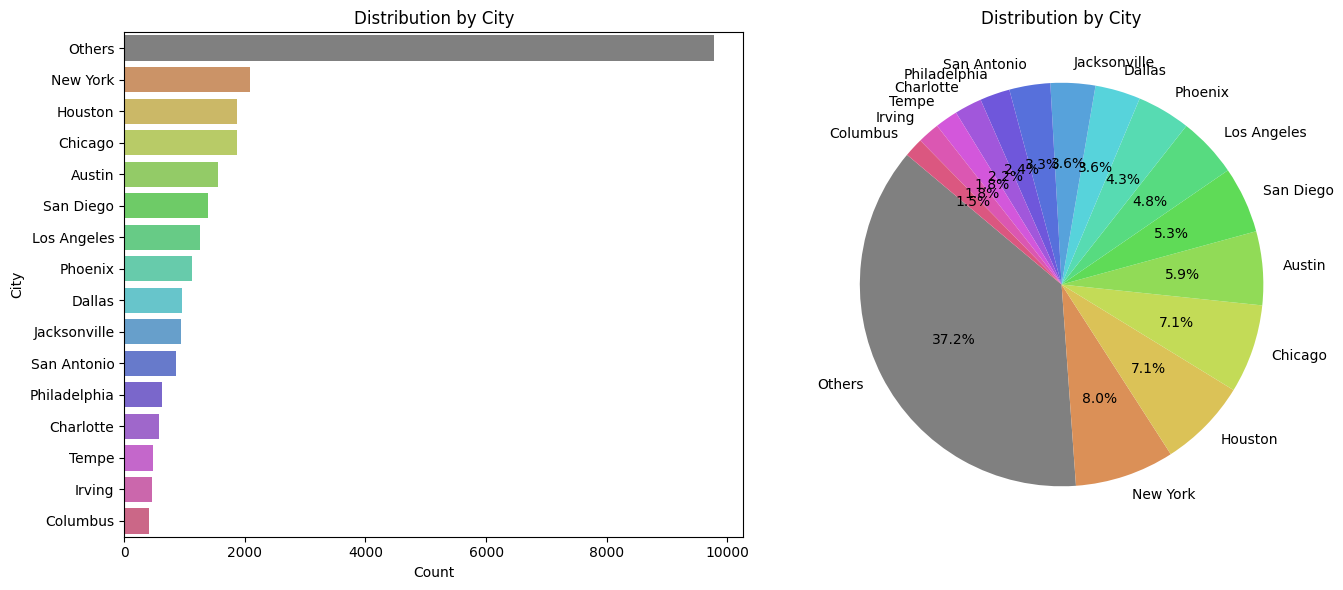

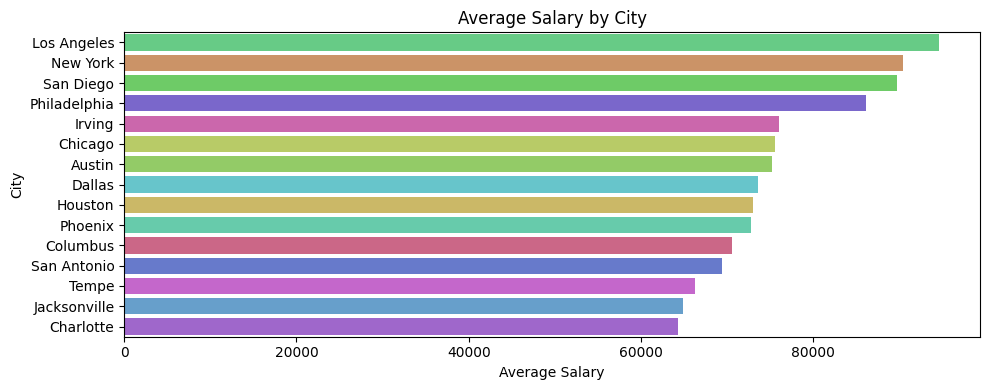

In [85]:
filtered_category = df['City']
category_counts = filtered_category.value_counts()

total_count = category_counts.sum()
threshold = 0.015 * total_count

filtered_category_updated = filtered_category.where(filtered_category.isin(category_counts[category_counts > threshold].index), 'Others')
category_counts_updated = filtered_category_updated.value_counts()

categories_updated = category_counts_updated.index
palette = sns.color_palette('hls', len(categories_updated))
palette_dict_others = {category: palette[i] for i, category in enumerate(categories_updated)}
palette_dict_others['Others'] = 'gray'

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=category_counts_updated.index, x=category_counts_updated.values, hue = category_counts_updated.index, legend = False, palette=palette_dict_others)
plt.title('Distribution by City')
plt.xlabel('Count')
plt.ylabel('City')

plt.subplot(1, 2, 2)
plt.pie(category_counts_updated.values, labels=category_counts_updated.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict_others.get(category, 'gray') for category in category_counts_updated.index])
plt.title('Distribution by City')
plt.tight_layout()
plt.show()

category_salary_avg = df.groupby('City')['SalaryAvg'].mean()
filtered_salary_avg = category_salary_avg[category_salary_avg.index.isin(category_counts_updated.index)].sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(y=filtered_salary_avg.index, x=filtered_salary_avg.values, hue = filtered_salary_avg.index, legend = False, palette=palette_dict_others)
plt.xlabel('Average Salary')
plt.ylabel('City')
plt.title('Average Salary by City')
plt.tight_layout()
plt.show()


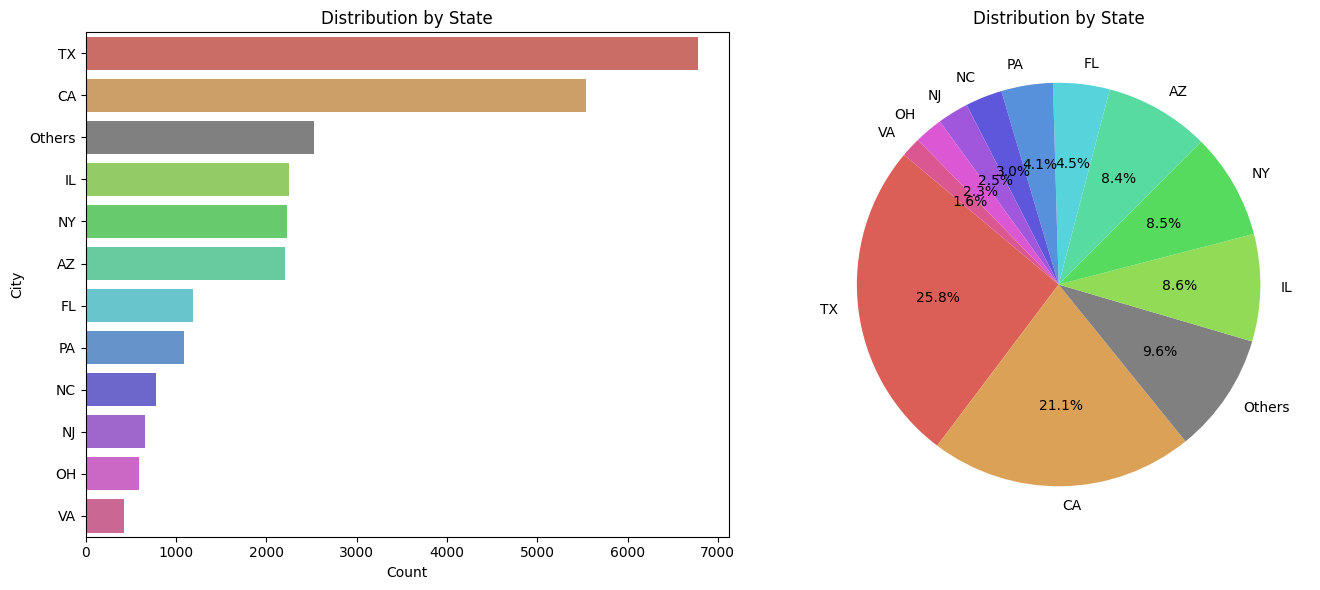

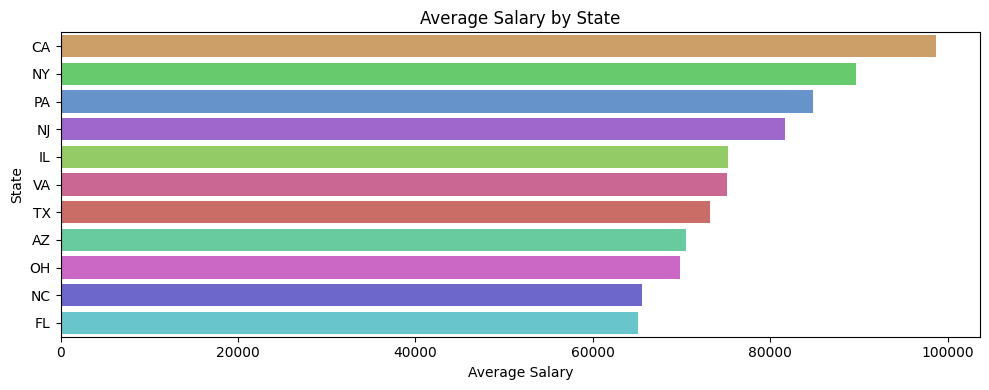

In [86]:
filtered_category = df['State']
category_counts = filtered_category.value_counts()

total_count = category_counts.sum()
threshold = 0.015 * total_count

filtered_category_updated = filtered_category.where(filtered_category.isin(category_counts[category_counts > threshold].index), 'Others')
category_counts_updated = filtered_category_updated.value_counts()

categories_updated = category_counts_updated.index
palette = sns.color_palette('hls', len(categories_updated))
palette_dict_others = {category: palette[i] for i, category in enumerate(categories_updated)}
palette_dict_others['Others'] = 'gray'

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=category_counts_updated.index, x=category_counts_updated.values, hue = category_counts_updated.index, legend = False, palette=palette_dict_others)
plt.title('Distribution by State')
plt.xlabel('Count')
plt.ylabel('City')

plt.subplot(1, 2, 2)
plt.pie(category_counts_updated.values, labels=category_counts_updated.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict_others.get(category, 'gray') for category in category_counts_updated.index])
plt.title('Distribution by State')
plt.tight_layout()
plt.show()

category_salary_avg = df.groupby('State')['SalaryAvg'].mean()
filtered_salary_avg = category_salary_avg[category_salary_avg.index.isin(category_counts_updated.index)].sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(y=filtered_salary_avg.index, x=filtered_salary_avg.values, hue = filtered_salary_avg.index, legend = False, palette=palette_dict_others)
plt.xlabel('Average Salary')
plt.ylabel('State')
plt.title('Average Salary by State')
plt.tight_layout()
plt.show()


## Headquarters

In [87]:
df['Headquarters'] = df['Headquarters'].replace(['-1'], 'Unknown')
unique_feature = df['Headquarters'].nunique()
print(unique_feature)
print(df['Headquarters'].value_counts().head(10))

1367
Headquarters
New York, NY         1943
Unknown              1313
Chicago, IL           985
San Diego, CA         774
Houston, TX           748
Los Angeles, CA       639
Woodridge, IL         578
Austin, TX            438
San Francisco, CA     427
Dallas, TX            387
Name: count, dtype: int64


In [88]:
def extract_city_state(location):
    parts = location.split(',')

    if len(parts) == 2:
        city, state = parts[0].strip(), parts[1].strip()
        if len(state) == 2:
            return city, state
        else:
            return city, "Unknown"

    elif len(parts) == 3:
        city = parts[0].strip()
        state = parts[2].strip()
        return city, state

    else:
        city = parts[0].strip()
        state = "Unknown"
        return city, state

df[['HeadquartersCity', 'HeadquartersState']] = df['Headquarters'].apply(lambda x: pd.Series(extract_city_state(x)))
df = df.drop(columns=['Headquarters'])
df.head(1)

,Job Title,JobDescriptionCleaned,Rating,Company Name,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory,Python,Spark,ExperienceLevel,Degree,City,State,HeadquartersCity,HeadquartersState
0,business analyst - clinical & logistics platform,company overview\n\n\nat memorial sloan ketter...,3.9,memorial sloan-kettering,10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0,Business Analyst,0.0,0.0,Unknown,Bachelor,New York,NY,New York,NY


In [89]:
unique_feature = df['HeadquartersCity'].nunique()
print(unique_feature)
unique_feature = df['HeadquartersState'].nunique()
print(unique_feature)

1268
54


In [90]:
df['HeadquartersState'].isnull().sum()

np.int64(0)

In [91]:
df[df['HeadquartersState'] == 'Unknown'][['HeadquartersState', 'HeadquartersCity']]

,HeadquartersState,HeadquartersCity
6,Unknown,Zurich
14,Unknown,London
15,Unknown,Amsterdam
24,Unknown,London
28,Unknown,Tokyo
...,...,...
26958,Unknown,Unknown
26962,Unknown,Chennai
26968,Unknown,Brussel
26969,Unknown,Brussel


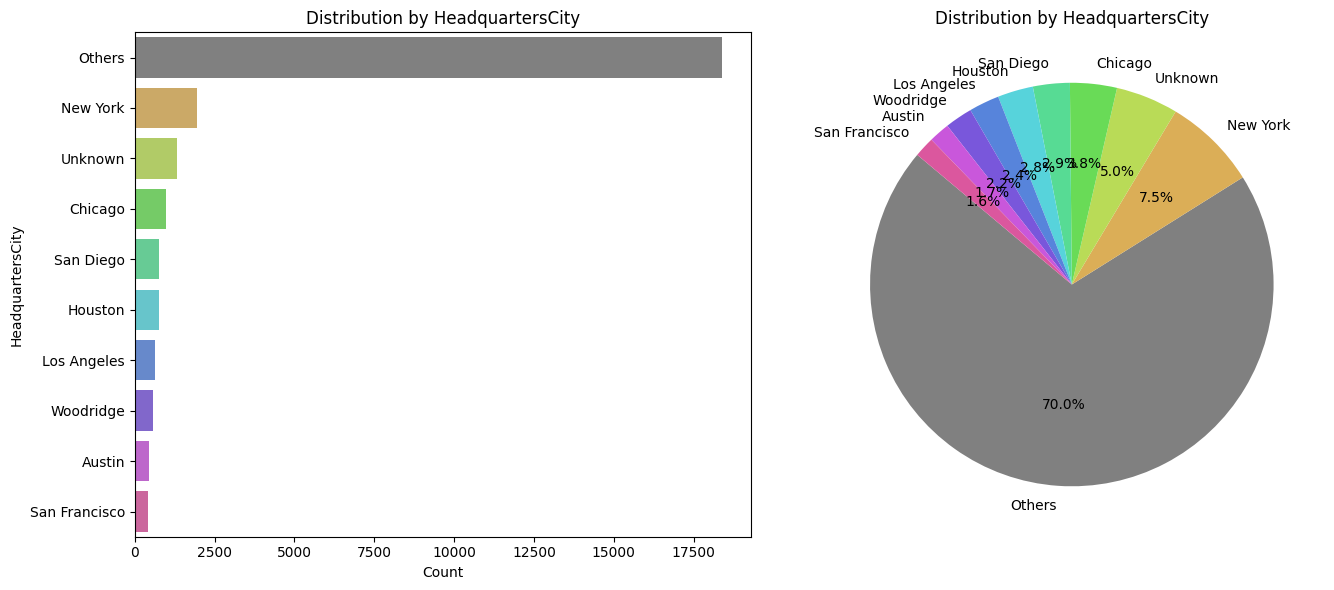

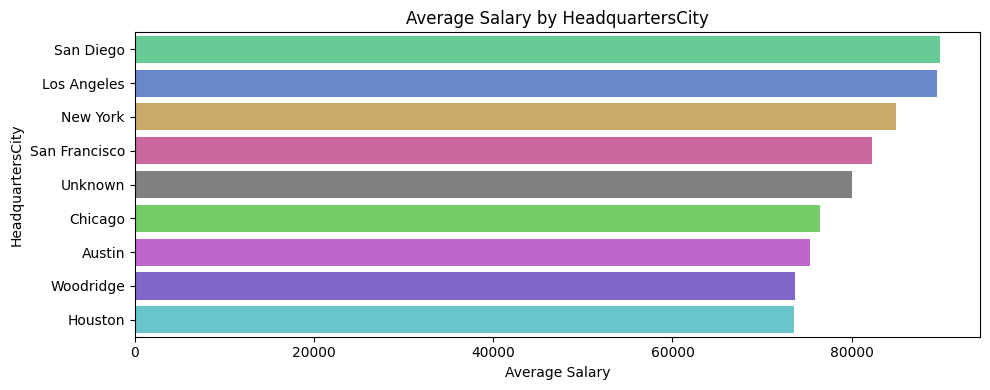

In [92]:
filtered_category = df['HeadquartersCity']
category_counts = filtered_category.value_counts()

total_count = category_counts.sum()
threshold = 0.015 * total_count

filtered_category_updated = filtered_category.where(filtered_category.isin(category_counts[category_counts > threshold].index), 'Others')
category_counts_updated = filtered_category_updated.value_counts()

categories_updated = category_counts_updated.index
palette = sns.color_palette('hls', len(categories_updated))
palette_dict_others = {category: palette[i] for i, category in enumerate(categories_updated)}
palette_dict_others['Others'] = 'gray'

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=category_counts_updated.index, x=category_counts_updated.values, hue = category_counts_updated.index, legend = False, palette=palette_dict_others)
plt.title('Distribution by HeadquartersCity')
plt.xlabel('Count')
plt.ylabel('HeadquartersCity')

plt.subplot(1, 2, 2)
plt.pie(category_counts_updated.values, labels=category_counts_updated.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict_others.get(category, 'gray') for category in category_counts_updated.index])
plt.title('Distribution by HeadquartersCity')
plt.tight_layout()
plt.show()

category_salary_avg = df.groupby('HeadquartersCity')['SalaryAvg'].mean()
filtered_salary_avg = category_salary_avg[category_salary_avg.index.isin(category_counts_updated.index)].sort_values(ascending=False)
plt.figure(figsize=(10, 4))
palette_dict_others['Unknown'] = 'gray'
sns.barplot(y=filtered_salary_avg.index, x=filtered_salary_avg.values, hue = filtered_salary_avg.index, legend = False, palette=palette_dict_others)
plt.xlabel('Average Salary')
plt.ylabel('HeadquartersCity')
plt.title('Average Salary by HeadquartersCity')
plt.tight_layout()
plt.show()


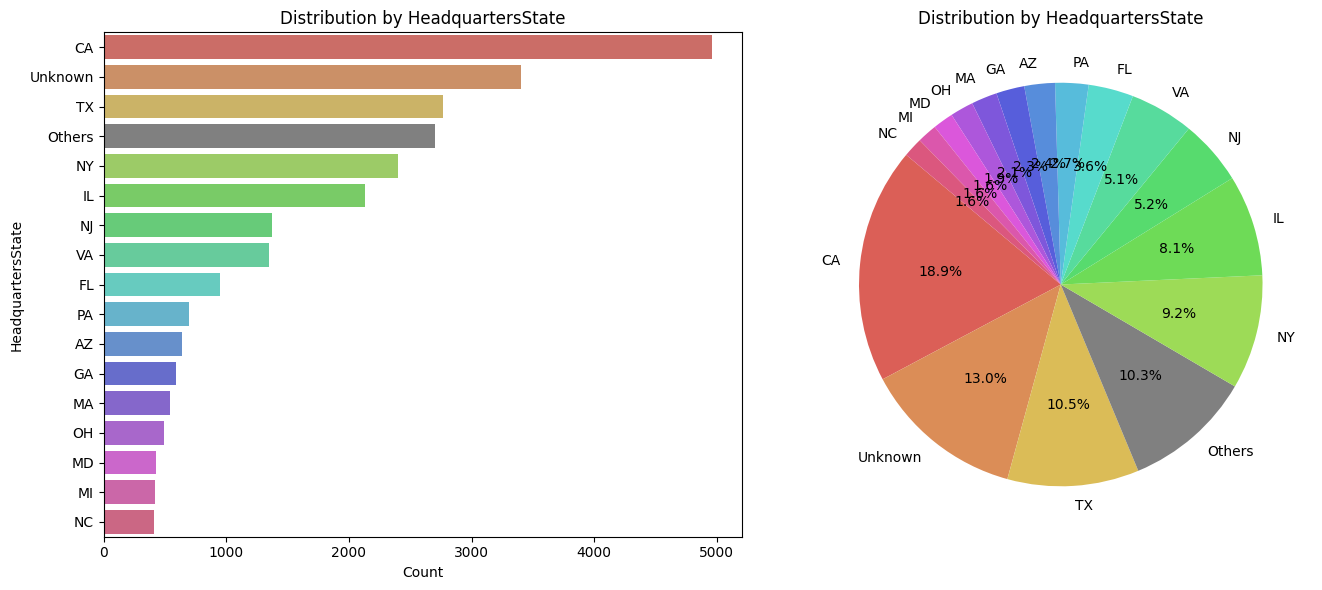

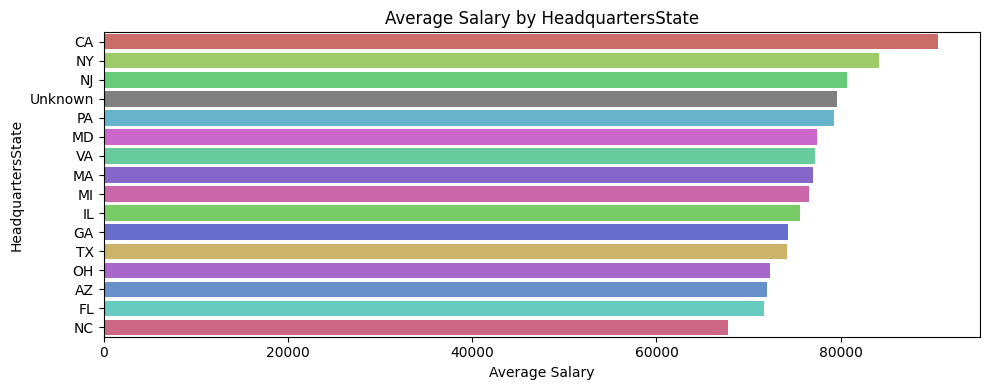

In [93]:
filtered_category = df['HeadquartersState']
category_counts = filtered_category.value_counts()

total_count = category_counts.sum()
threshold = 0.015 * total_count

filtered_category_updated = filtered_category.where(filtered_category.isin(category_counts[category_counts > threshold].index), 'Others')
category_counts_updated = filtered_category_updated.value_counts()

categories_updated = category_counts_updated.index
palette = sns.color_palette('hls', len(categories_updated))
palette_dict_others = {category: palette[i] for i, category in enumerate(categories_updated)}
palette_dict_others['Others'] = 'gray'

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=category_counts_updated.index, x=category_counts_updated.values, hue = category_counts_updated.index, legend = False, palette=palette_dict_others)
plt.title('Distribution by HeadquartersState')
plt.xlabel('Count')
plt.ylabel('HeadquartersState')

plt.subplot(1, 2, 2)
plt.pie(category_counts_updated.values, labels=category_counts_updated.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict_others.get(category, 'gray') for category in category_counts_updated.index])
plt.title('Distribution by HeadquartersState')
plt.tight_layout()
plt.show()

category_salary_avg = df.groupby('HeadquartersState')['SalaryAvg'].mean()
filtered_salary_avg = category_salary_avg[category_salary_avg.index.isin(category_counts_updated.index)].sort_values(ascending=False)
plt.figure(figsize=(10, 4))
palette_dict_others['Unknown'] = 'gray'
sns.barplot(y=filtered_salary_avg.index, x=filtered_salary_avg.values, hue = filtered_salary_avg.index, legend = False, palette=palette_dict_others)
plt.xlabel('Average Salary')
plt.ylabel('HeadquartersState')
plt.title('Average Salary by HeadquartersState')
plt.tight_layout()
plt.show()


## Size

In [94]:
df['Size'] = df['Size'].replace(['-1', 'Unknown'], 'Unknown')
unique_feature = df['Size'].nunique()
print(unique_feature)
print(df['Size'].value_counts().head(10))

8
Size
10000+ employees           6310
1001 to 5000 employees     4415
51 to 200 employees        4365
1 to 50 employees          3175
201 to 500 employees       2551
501 to 1000 employees      2073
Unknown                    1776
5001 to 10000 employees    1583
Name: count, dtype: int64


In [95]:
categories = df['Size'].unique()
palette = sns.color_palette('hls', len(categories))
palette_dict = {category: palette[i] for i, category in enumerate(categories)}

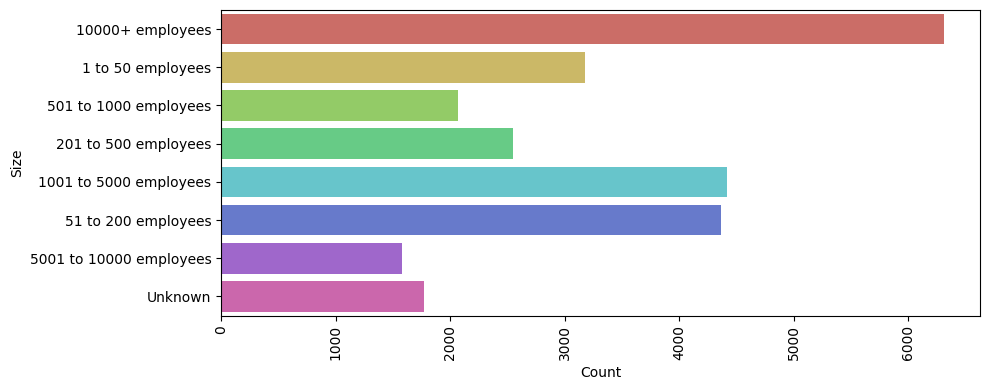

In [96]:
plt.figure(figsize=(10, 4))
sns.countplot(y='Size', data=df, hue = 'Size', legend = False, palette=palette_dict)
plt.xticks(rotation=90)
plt.ylabel('Size')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

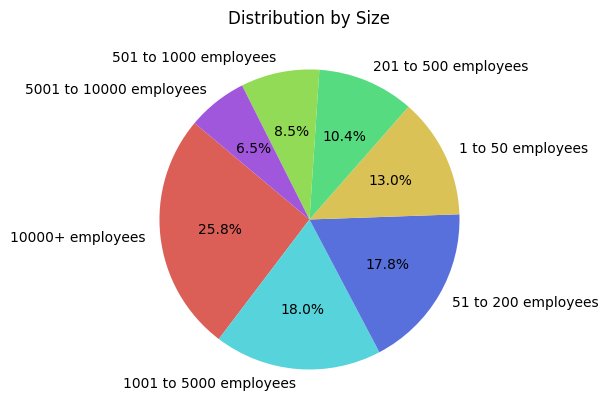

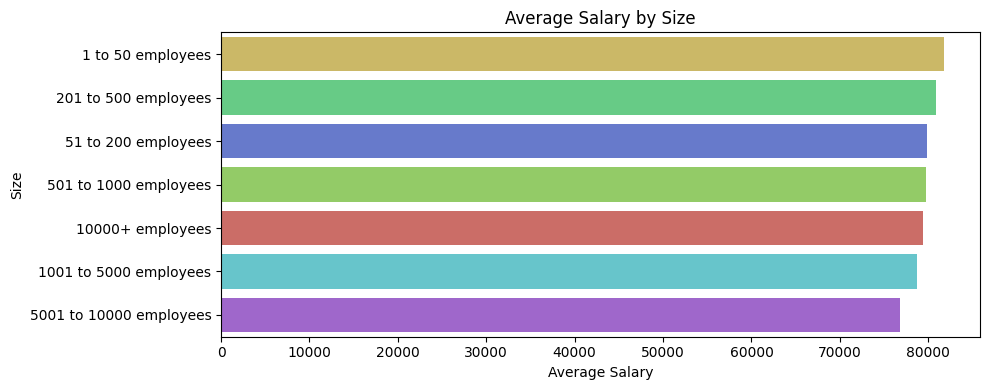

In [97]:
filtered_size = df[df['Size'] != 'Unknown']
size_counts = filtered_size['Size'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(size_counts.values, labels=size_counts.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict[category] for category in size_counts.index])

plt.title('Distribution by Size')
plt.tight_layout()
plt.show()

category_salary_avg = filtered_size.groupby('Size')['SalaryAvg'].mean().sort_values(ascending=False)
# print("Average Salary for Revenue:")
# print(category_salary_avg)

plt.figure(figsize=(10, 4))
sns.barplot(y=category_salary_avg.index, x=category_salary_avg.values, hue=category_salary_avg.index, legend=False, palette=palette_dict)
plt.xlabel('Average Salary')
plt.ylabel('Size')
plt.title('Average Salary by Size')
plt.tight_layout()
plt.show()


## Type of ownership

In [98]:
df['Type of ownership'] = df['Type of ownership'].replace(['-1'], 'Unknown')
unique_feature = df['Type of ownership'].nunique()
print(unique_feature)
print(df['Type of ownership'].value_counts().head(15))

14
Type of ownership
Company - Private                 13605
Company - Public                   7386
Unknown                            1452
Subsidiary or Business Segment     1137
Nonprofit Organization             1094
Government                          640
College / University                326
Hospital                            163
Contract                            134
Private Practice / Firm             111
Other Organization                   93
School / School District             75
Franchise                            17
Self-employed                        15
Name: count, dtype: int64


In [99]:
categories = df['Type of ownership'].unique()
palette = sns.color_palette('hls', len(categories))
palette_dict = {category: palette[i] for i, category in enumerate(categories)}

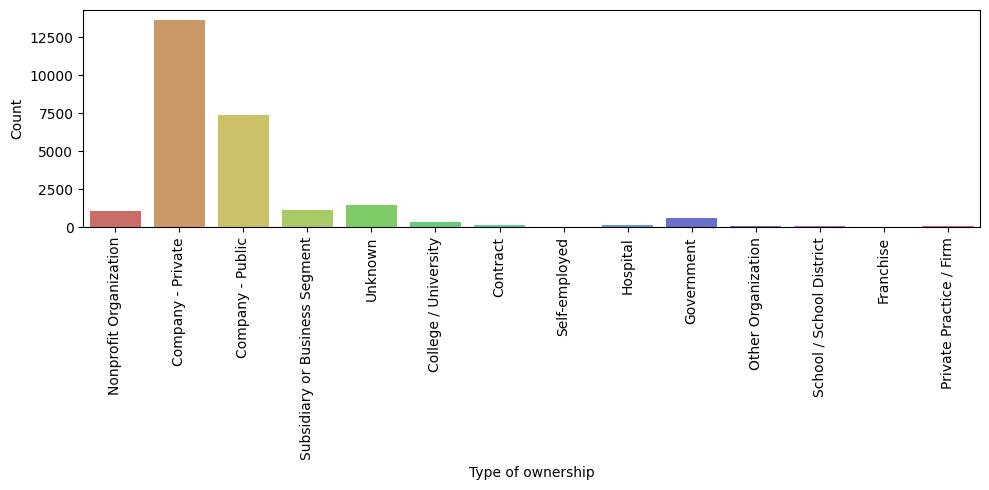

In [100]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Type of ownership', data=df, hue = 'Type of ownership', legend = False, palette=palette_dict)
plt.xticks(rotation=90)
plt.xlabel('Type of ownership')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

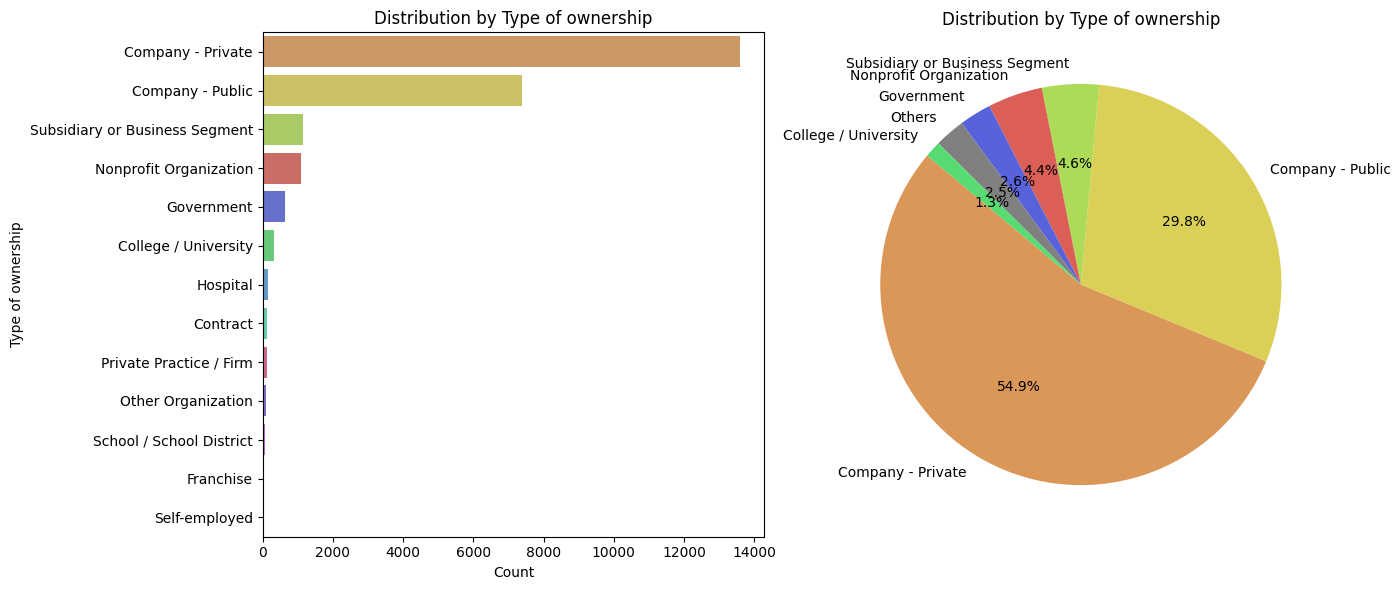

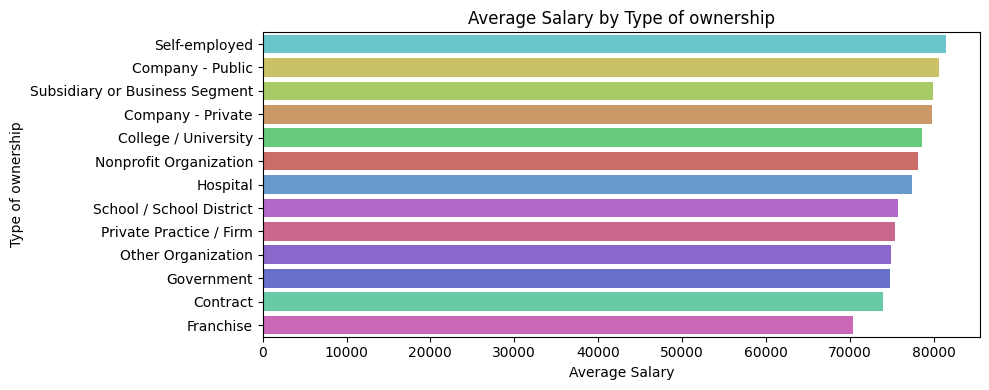

In [101]:
filtered_category = df[df['Type of ownership'] != 'Unknown']
category_counts = filtered_category['Type of ownership'].value_counts()

total_count = category_counts.sum()
threshold = 0.01 * total_count

filtered_category_updated=filtered_category.copy()
others = category_counts[category_counts < threshold].index
filtered_category_updated['Type of ownership'] = filtered_category_updated['Type of ownership'].replace(others, 'Others')
category_counts_updated = filtered_category_updated['Type of ownership'].value_counts()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=category_counts.index, x=category_counts.values, hue = category_counts.index, legend = False,
            palette=palette_dict)
plt.title('Distribution by Type of ownership')
plt.xlabel('Count')
plt.ylabel('Type of ownership')

# category_counts_filtered = category_counts_updated[category_counts_updated > 300]
palette_dict_others=palette_dict.copy()
palette_dict_others['Others'] = 'gray'
plt.subplot(1, 2, 2)
plt.pie(category_counts_updated.values, labels=category_counts_updated.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict_others.get(category, 'gray') for category in category_counts_updated.index])
plt.title('Distribution by Type of ownership')

plt.tight_layout()
plt.show()
#
category_salary_avg = filtered_category.groupby('Type of ownership')['SalaryAvg'].mean().sort_values(ascending=False)
# print("Average Salary for Revenue:")
# print(category_salary_avg)

plt.figure(figsize=(10, 4))
sns.barplot(y=category_salary_avg.index, x=category_salary_avg.values, hue=category_salary_avg.index, legend=False, palette=palette_dict)
plt.xlabel('Average Salary')
plt.ylabel('Type of ownership')
plt.title('Average Salary by Type of ownership')
plt.tight_layout()
plt.show()


## Sector & Industry

In [102]:
df['Sector'] = df['Sector'].replace(['-1'], 'Unknown')

unique_salaries = df['Sector'].nunique()
print(unique_salaries)
print(df['Sector'].value_counts().head(26))



26
Sector
Information Technology                6571
Business Services                     5215
Unknown                               3297
Finance                               2439
Health Care                           1383
Insurance                              952
Manufacturing                          865
Biotech & Pharmaceuticals              656
Aerospace & Defense                    627
Government                             612
Accounting & Legal                     558
Retail                                 545
Education                              530
Oil, Gas, Energy & Utilities           393
Media                                  381
Transportation & Logistics             231
Non-Profit                             196
Real Estate                            191
Telecommunications                     173
Construction, Repair & Maintenance     139
Consumer Services                      127
Restaurants, Bars & Food Services       61
Travel & Tourism                        46
A

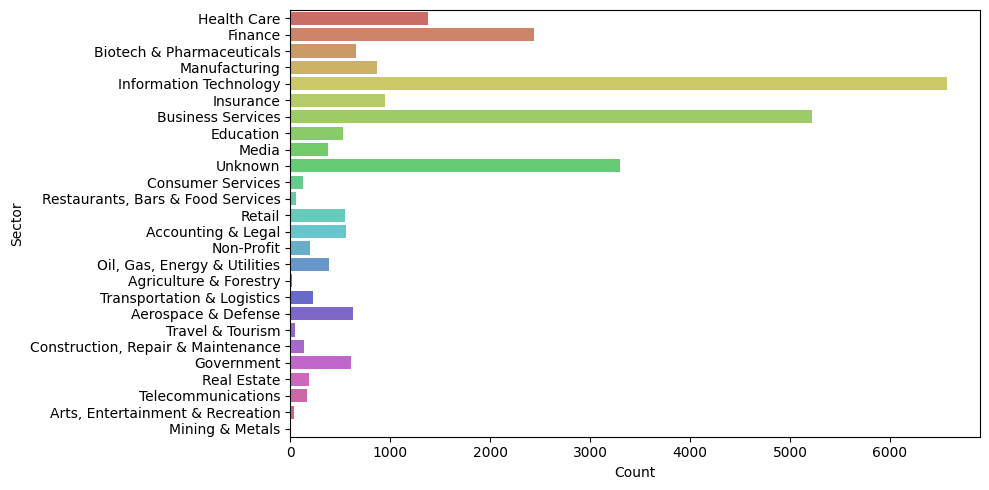

In [103]:
categories = df['Sector'].unique()
palette = sns.color_palette('hls', len(categories))
palette_dict = {category: palette[i] for i, category in enumerate(categories)}

plt.figure(figsize=(10, 5))
sns.countplot(y='Sector', data=df, hue='Sector', legend=False, palette=palette_dict)
plt.xlabel('Count')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

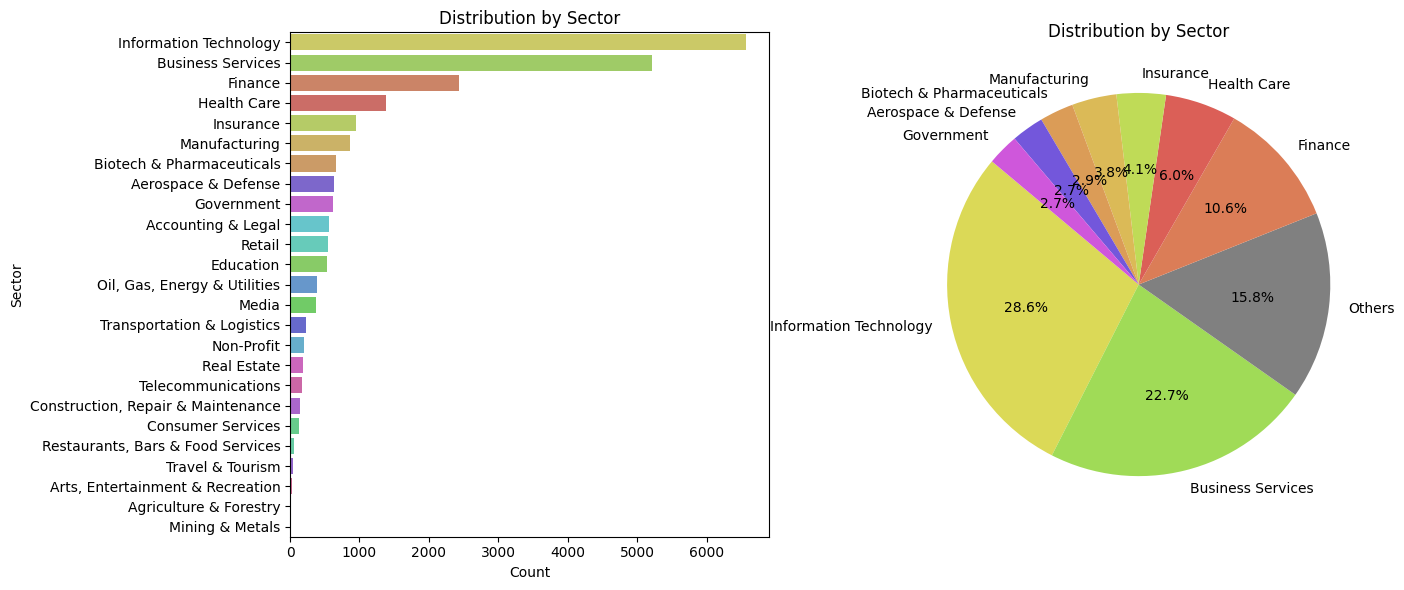

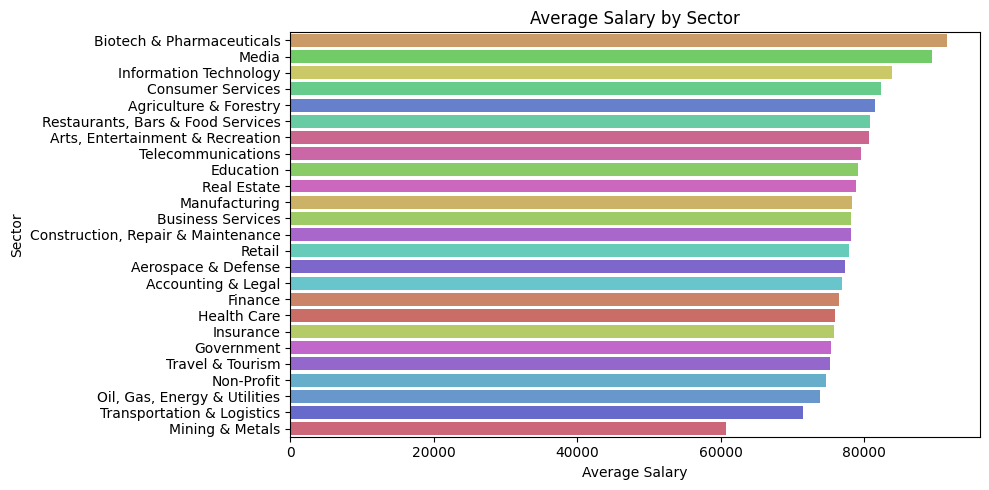

In [104]:
filtered_category = df[df['Sector'] != 'Unknown']
category_counts = filtered_category['Sector'].value_counts()

total_count = category_counts.sum()
threshold = 0.025 * total_count

filtered_category_updated=filtered_category.copy()
others = category_counts[category_counts <= threshold].index
filtered_category_updated['Sector'] = filtered_category_updated['Sector'].replace(others, 'Others')
category_counts_updated = filtered_category_updated['Sector'].value_counts()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(y=category_counts.index, x=category_counts.values, hue = category_counts.index, legend = False, palette=palette_dict)
plt.title('Distribution by Sector')
plt.xlabel('Count')
plt.ylabel('Sector')

# category_counts_filtered = category_counts_updated[category_counts_updated > 300]
palette_dict_others=palette_dict.copy()
palette_dict_others['Others'] = 'gray'
plt.subplot(1, 2, 2)
plt.pie(category_counts_updated.values, labels=category_counts_updated.index, autopct='%1.1f%%', startangle=140,
        colors=[palette_dict_others.get(category, 'gray') for category in category_counts_updated.index])
plt.title('Distribution by Sector')

plt.tight_layout()
plt.show()
#


category_salary_avg = filtered_category.groupby('Sector')['SalaryAvg'].mean().sort_values(ascending=False)
# print("Average Salary for Revenue:")
# print(category_salary_avg)

plt.figure(figsize=(10, 5))
sns.barplot(y=category_salary_avg.index, x=category_salary_avg.values, hue=category_salary_avg.index, legend=False, palette=palette_dict)
plt.xlabel('Average Salary')
plt.ylabel('Sector')
plt.title('Average Salary by Sector')
plt.tight_layout()
plt.show()


In [105]:
df['Industry'] = df['Industry'].replace(['-1'], 'Unknown')
unique_salaries = df['Industry'].nunique()
print(unique_salaries)
print(df['Industry'].value_counts().head(10))

122
Industry
IT Services                                3434
Unknown                                    3300
Staffing & Outsourcing                     2519
Consulting                                 1601
Computer Hardware & Software               1549
Health Care Services & Hospitals           1383
Investment Banking & Asset Management      1020
Enterprise Software & Network Solutions     877
Insurance Carriers                          846
Banks & Credit Unions                       767
Name: count, dtype: int64


In [106]:
filtered_sectors = ['Information Technology', 'Business Services', 'Finance', 'Health Care', 'Insurance', 'Manufacturing', 'Biotech & Pharmaceuticals', 'Media']
filtered_df = df[df['Sector'].isin(filtered_sectors)]
for sector in filtered_sectors:
    industries_in_sector = filtered_df[filtered_df['Sector'] == sector]['Industry'].unique()
    print(f"\nIndustries in {sector}:")
    print(industries_in_sector)



Industries in Information Technology:
['Internet' 'Computer Hardware & Software'
 'Enterprise Software & Network Solutions' 'IT Services' 'Unknown']

Industries in Business Services:
['Architectural & Engineering Services' 'Consulting'
 'Staffing & Outsourcing' 'Advertising & Marketing' 'Wholesale'
 'Building & Personnel Services' 'Research & Development'
 'Security Services' 'Membership Organizations'
 'Commercial Equipment Rental' 'Business Service Centers & Copy Shops']

Industries in Finance:
['Venture Capital & Private Equity'
 'Investment Banking & Asset Management'
 'Financial Transaction Processing' 'Lending' 'Banks & Credit Unions'
 'Stock Exchanges' 'Brokerage Services' 'Financial Analytics & Research']

Industries in Health Care:
['Health Care Services & Hospitals']

Industries in Insurance:
['Insurance Agencies & Brokerages' 'Insurance Carriers']

Industries in Manufacturing:
['Health Care Products Manufacturing' 'Food & Beverage Manufacturing'
 'Chemical Manufacturing' 'C

Information Technology


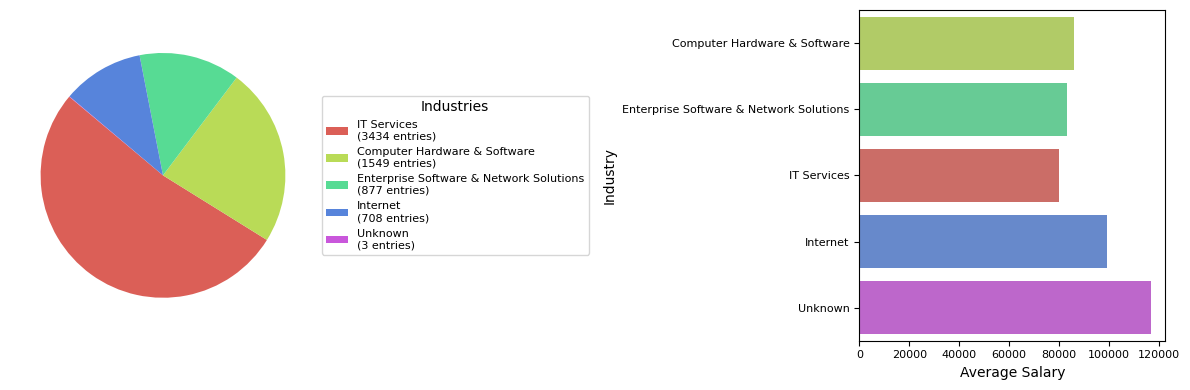

Business Services


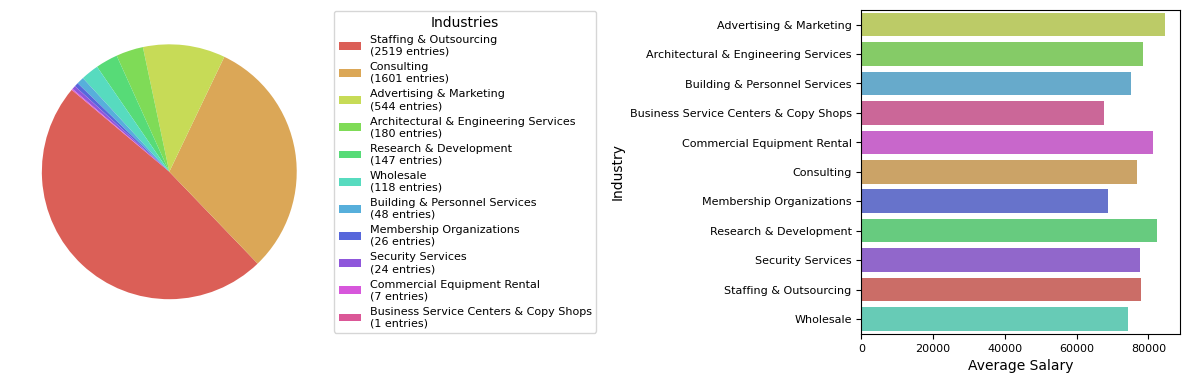

Finance


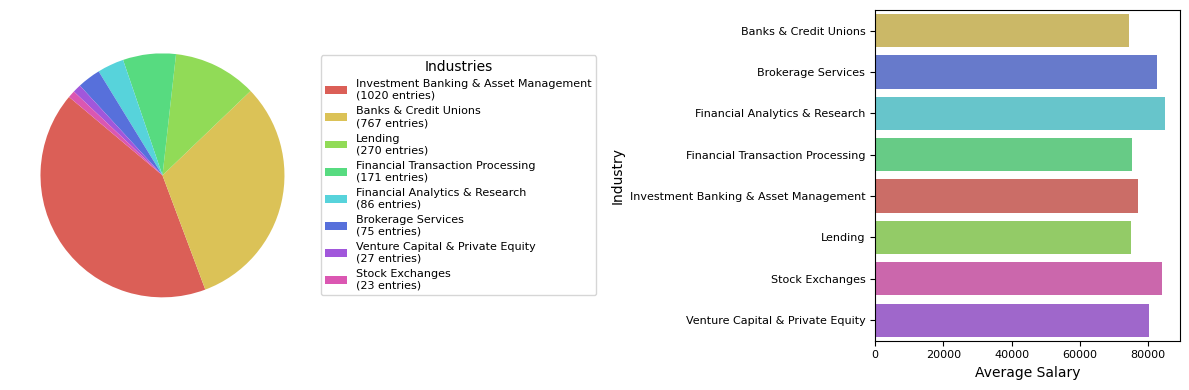

Insurance


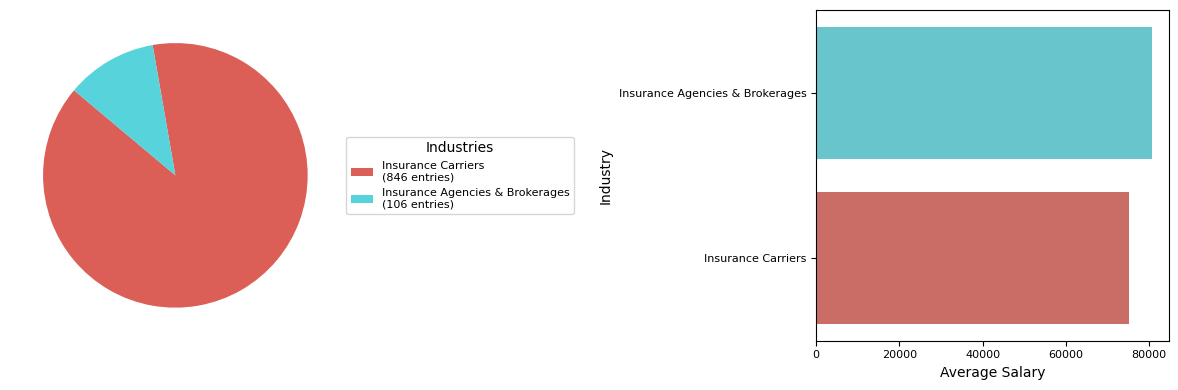

Manufacturing


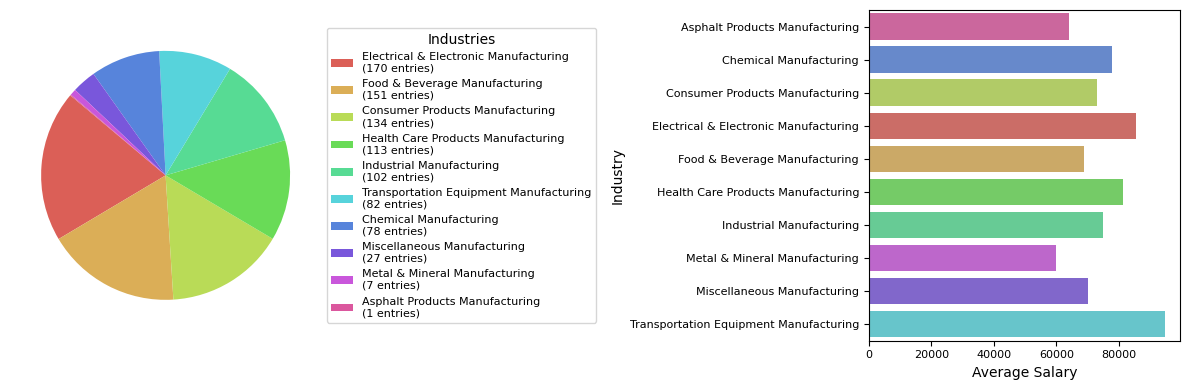

Media


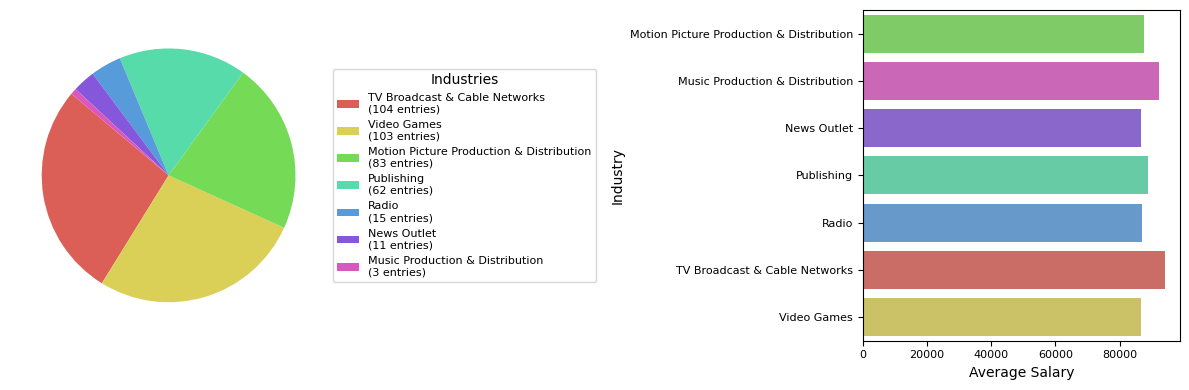

In [107]:
sectors_of_interest = ['Information Technology', 'Business Services', 'Finance', 'Insurance', 'Manufacturing', 'Media']

for sector in sectors_of_interest:
    print(f"{sector}")
    sector_df = df[df['Sector'] == sector]
    industry_counts = sector_df['Industry'].value_counts()
    avg_salary_by_industry = sector_df.groupby('Industry')['SalaryAvg'].mean()

    palette_dict = {industry: color for industry, color in zip(industry_counts.index, sns.color_palette("hls", len(industry_counts)))}

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    wedges, texts = plt.pie(industry_counts.values, labels=None, startangle=140,
                            colors=[palette_dict[industry] for industry in industry_counts.index])
    legend_labels = [
        f'{industry}\n({count} entries)'
        for industry, count in zip(industry_counts.index, industry_counts.values)
    ]
    plt.legend(wedges, legend_labels, title="Industries", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=8)

    plt.subplot(1, 2, 2)
    sns.barplot(x=avg_salary_by_industry.values, y=avg_salary_by_industry.index, hue=avg_salary_by_industry.index, palette=palette_dict)
    plt.xlabel('Average Salary')
    plt.ylabel('Industry')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.subplots_adjust(wspace=1)
    plt.tight_layout()
    plt.show()


## Revenue

In [108]:
df['Revenue'] = df['Revenue'].replace(['-1', 'Unknown / Non-Applicable'], 'Unknown')
unique_feature = df['Revenue'].nunique()
print(unique_feature)
print(df['Revenue'].value_counts().head(15))

13
Revenue
Unknown                             7742
$10+ billion (USD)                  3756
$100 to $500 million (USD)          2504
$50 to $100 million (USD)           1888
$2 to $5 billion (USD)              1626
$1 to $2 billion (USD)              1409
$10 to $25 million (USD)            1353
$25 to $50 million (USD)            1299
$1 to $5 million (USD)              1110
$5 to $10 billion (USD)             1012
$500 million to $1 billion (USD)    1004
$5 to $10 million (USD)              805
Less than $1 million (USD)           740
Name: count, dtype: int64


In [109]:
revenue_categories = df['Revenue'].unique()
palette = sns.color_palette('hls', len(revenue_categories))
palette_dict = {category: palette[i] for i, category in enumerate(revenue_categories)}

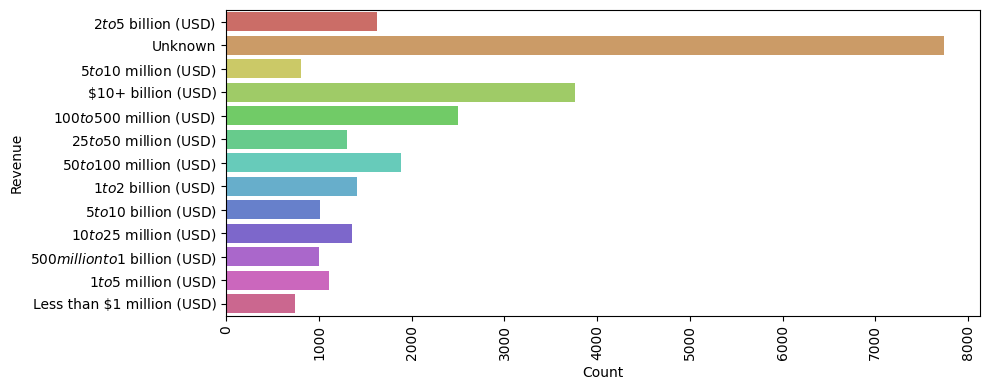

In [110]:
plt.figure(figsize=(10, 4))
sns.countplot(y='Revenue', data=df, hue = 'Revenue', legend = False, palette=palette_dict)
plt.xticks(rotation=90)
plt.ylabel('Revenue')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

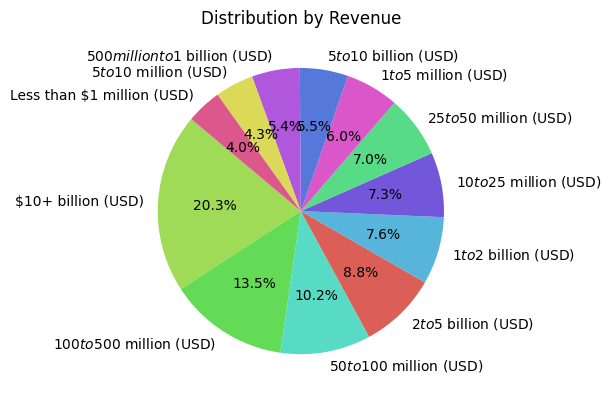

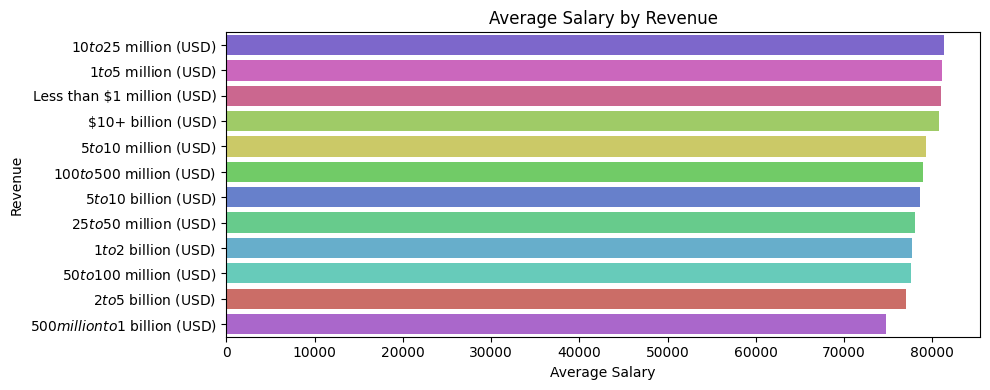

In [111]:
filtered_revenue = df[df['Revenue'] != 'Unknown']
revenue_counts = filtered_revenue['Revenue'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(revenue_counts.values, labels=revenue_counts.index, autopct='%1.1f%%', startangle=140, colors=[palette_dict[category] for category in revenue_counts.index])

plt.title('Distribution by Revenue')
plt.tight_layout()
plt.show()

category_salary_avg = filtered_revenue.groupby('Revenue')['SalaryAvg'].mean().sort_values(ascending=False)
# print("Average Salary for Revenue:")
# print(category_salary_avg)

plt.figure(figsize=(10, 4))
sns.barplot(y=category_salary_avg.index, x=category_salary_avg.values, hue=category_salary_avg.index, legend=False, palette=palette_dict)
plt.xlabel('Average Salary')
plt.ylabel('Revenue')
plt.title('Average Salary by Revenue')
plt.tight_layout()
plt.show()


# Processed Dataset Summary

Job Title                    0
JobDescriptionCleaned        0
Rating                       0
Company Name                 0
Size                      1776
Type of ownership         1452
Industry                  3300
Sector                    3297
Revenue                   7742
SalaryAvg                    0
JobCategory                  0
Python                       0
Spark                        0
ExperienceLevel          13345
Degree                    6483
City                       105
State                      105
HeadquartersCity          1313
HeadquartersState         3400
dtype: int64


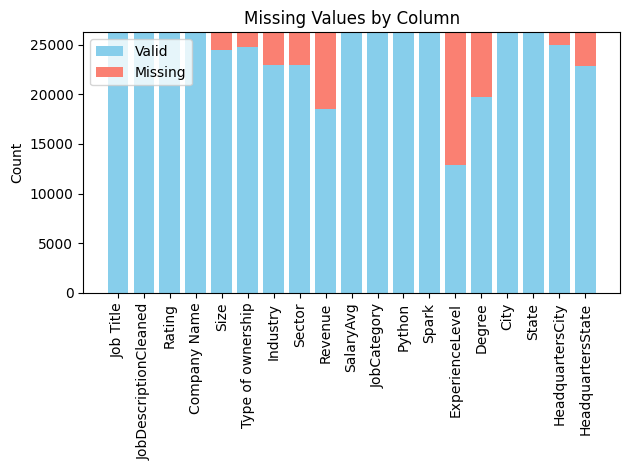

In [112]:
missing_counts = df.replace({-1: np.nan, 'Unknown': np.nan}).isnull().sum()
valid_counts = df.replace({-1: np.nan, 'Unknown': np.nan}).notnull().sum()
print(missing_counts)

categories = df.columns
x = range(len(categories))

plt.bar(x, valid_counts, label='Valid', color='skyblue')
plt.bar(x, missing_counts, bottom=valid_counts, label='Missing', color='salmon')
plt.xticks(x, categories, rotation=90)
plt.ylabel('Count')
plt.title('Missing Values by Column')
plt.legend()

plt.tight_layout()
plt.show()

In [113]:
df.head(1)

,Job Title,JobDescriptionCleaned,Rating,Company Name,Size,Type of ownership,Industry,Sector,Revenue,SalaryAvg,JobCategory,Python,Spark,ExperienceLevel,Degree,City,State,HeadquartersCity,HeadquartersState
0,business analyst - clinical & logistics platform,company overview\n\n\nat memorial sloan ketter...,3.9,memorial sloan-kettering,10000+ employees,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),79000.0,Business Analyst,0.0,0.0,Unknown,Bachelor,New York,NY,New York,NY


In [114]:
columns_to_save = [
    'Job Title', 'Rating', 'Company Name', 'City', 'State', 'HeadquartersCity', 'HeadquartersState', 'Size',
    'Type of ownership', 'Industry', 'Sector', 'Revenue', 'SalaryAvg',
    'JobCategory', 'Python', 'Spark', 'ExperienceLevel', 'Degree'
]

df_selected = df[columns_to_save]

df_selected.to_csv('selected_job_data.csv', index=False)
del df_selected


# Machine Learning Pipeline (Salary Prediction)

## Data Encoding & Preparation

In [115]:
selected_columns = ['Rating', 'Company Name', 'JobCategory', 'Size', 'Revenue', 'Type of ownership', 'Industry',	'City', 'State', 'HeadquartersCity', 'HeadquartersState', 'SalaryAvg'
 , 'Python', 'Spark', 'Degree'
]
df_selected = df[selected_columns].copy()
print(df_selected.head())
del df

   Rating              Company Name       JobCategory                   Size  \
0     3.9  memorial sloan-kettering  Business Analyst       10000+ employees   
1     3.8   paine schwartz partners  Business Analyst      1 to 50 employees   
2     3.6                   asembia      Data Analyst  501 to 1000 employees   
3     3.6                        bd  Business Analyst       10000+ employees   
4     3.4           rubicon project  Business Analyst   201 to 500 employees   

                      Revenue       Type of ownership  \
0      $2 to $5 billion (USD)  Nonprofit Organization   
1                     Unknown       Company - Private   
2     $5 to $10 million (USD)       Company - Private   
3          $10+ billion (USD)        Company - Public   
4  $100 to $500 million (USD)        Company - Public   

                             Industry            City State HeadquartersCity  \
0    Health Care Services & Hospitals        New York    NY         New York   
1    Venture Cap

In [116]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26248 entries, 0 to 26979
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             26248 non-null  float64
 1   Company Name       26248 non-null  object 
 2   JobCategory        26248 non-null  object 
 3   Size               26248 non-null  object 
 4   Revenue            26248 non-null  object 
 5   Type of ownership  26248 non-null  object 
 6   Industry           26248 non-null  object 
 7   City               26248 non-null  object 
 8   State              26248 non-null  object 
 9   HeadquartersCity   26248 non-null  object 
 10  HeadquartersState  26248 non-null  object 
 11  SalaryAvg          26248 non-null  float64
 12  Python             26248 non-null  float64
 13  Spark              26248 non-null  float64
 14  Degree             26248 non-null  object 
dtypes: float64(4), object(11)
memory usage: 3.2+ MB


### Train/Test Split

In [117]:
X = df_selected.drop(columns=['SalaryAvg'])
y = df_selected['SalaryAvg']

print("X")
print(X.head())
print("\ny")
print(y.head())

X
   Rating              Company Name       JobCategory                   Size  \
0     3.9  memorial sloan-kettering  Business Analyst       10000+ employees   
1     3.8   paine schwartz partners  Business Analyst      1 to 50 employees   
2     3.6                   asembia      Data Analyst  501 to 1000 employees   
3     3.6                        bd  Business Analyst       10000+ employees   
4     3.4           rubicon project  Business Analyst   201 to 500 employees   

                      Revenue       Type of ownership  \
0      $2 to $5 billion (USD)  Nonprofit Organization   
1                     Unknown       Company - Private   
2     $5 to $10 million (USD)       Company - Private   
3          $10+ billion (USD)        Company - Public   
4  $100 to $500 million (USD)        Company - Public   

                             Industry            City State HeadquartersCity  \
0    Health Care Services & Hospitals        New York    NY         New York   
1    Venture C

In [118]:
# X.replace("Unknown", np.nan, inplace=True)

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [120]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (20998, 14), y_train shape: (20998,)
X_test shape: (5250, 14), y_test shape: (5250,)


### Feature Scaling

In [121]:
numerical_columns = ['Rating']
# Scale Rating (fit only on train data to prevent data leakage)
scaler_X = MinMaxScaler()
X_train['Rating'] = scaler_X.fit_transform(X_train[['Rating']])
X_test['Rating'] = scaler_X.transform(X_test[['Rating']])



In [122]:
print(f"X_train['Rating'] range: {X_train['Rating'].min():.2f} to {X_train['Rating'].max():.2f}")

X_train['Rating'] range: 0.00 to 1.00


In [123]:
# Scale Target (fit only on train data)
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).squeeze()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).squeeze()

In [124]:
print(f"y_train_scaled range: {y_train_scaled.min():.2f} to {y_train_scaled.max():.2f}\n")

y_train_scaled range: 0.00 to 1.00



In [125]:
# Convert back to pandas Series to keep index alignment for TargetEncoder
y_train_scaled = pd.Series(y_train_scaled, index=y_train.index)
y_test_scaled = pd.Series(y_test_scaled, index=y_test.index)

### Categorical Encoding

In [126]:
# OrdinalEncoding
size_mapping = {
    '1 to 50 employees': 1,
    '51 to 200 employees': 2,
    '201 to 500 employees': 3,
    '501 to 1000 employees': 4,
    '1001 to 5000 employees': 5,
    '5001 to 10000 employees': 6,
    '10000+ employees': 7,
    'Unknown': 0
}

revenue_mapping = {
    'Unknown': 0,
    'Less than $1 million (USD)': 1,
    '$1 to $5 million (USD)': 2,
    '$5 to $10 million (USD)': 3,
    '$10 to $25 million (USD)': 4,
    '$25 to $50 million (USD)': 5,
    '$50 to $100 million (USD)': 6,
    '$100 to $500 million (USD)': 7,
    '$500 million to $1 billion (USD)': 8,
    '$1 to $2 billion (USD)': 9,
    '$2 to $5 billion (USD)': 10,
    '$5 to $10 billion (USD)': 11,
    '$10+ billion (USD)': 12
}

# level_mapping = {
#     'Unknown': 0,
#     'Senior' :4,
#     'Junior' :2,
#     'Middle'   :3,
#     'Intern/Trainee' :1
# }

degree_mapping = {
    'Unknown': 0,
    'Bachelor' :1,
    'Master' :2,
    'PhD'   :3
}

for df_split in [X_train, X_test]:
    df_split['Size'] = df_split['Size'].map(size_mapping).fillna(0)
    df_split['Revenue'] = df_split['Revenue'].map(revenue_mapping).fillna(0)
    df_split['Degree'] = df_split['Degree'].map(degree_mapping).fillna(0)



In [127]:
X_train[['Size', 'Revenue', 'Degree']].head()

,Size,Revenue,Degree
14637,2,0,2
6930,4,7,1
2142,5,7,1
17529,7,12,1
18546,7,12,1


In [128]:
target_columns = ['Company Name', 'JobCategory', 'Industry','Type of ownership', 'City', 'State', 'HeadquartersCity', 'HeadquartersState']

# Initialize TargetEncoder
target_encoder = TargetEncoder(random_state=42)

In [129]:
# Fit Target Encoder only on the training set to avoid data leakage
X_train[target_columns] = target_encoder.fit_transform(X_train[target_columns], y_train_scaled)

# Transform the test set
X_test[target_columns] = target_encoder.transform(X_test[target_columns])

print("Data check after all transformations:")
print(X_train.head())

Data check after all transformations:
       Rating  Company Name  JobCategory  Size  Revenue  Type of ownership  \
14637   0.725      0.243846     0.205755     2        0           0.244026   
6930    0.725      0.245294     0.207869     4        7           0.244361   
2142    0.525      0.188562     0.219784     5        7           0.210519   
17529   0.625      0.242982     0.405517     7       12           0.249272   
18546   0.575      0.129921     0.220942     7       12           0.252165   

       Industry      City     State  HeadquartersCity  HeadquartersState  \
14637  0.245465  0.243846  0.145044          0.243846           0.242208   
6930   0.229703  0.296108  0.342441          0.209464           0.230334   
2142   0.234029  0.188398  0.208908          0.213614           0.232616   
17529  0.229844  0.299692  0.341973          0.232061           0.224036   
18546  0.216386  0.158854  0.297577          0.229299           0.219929   

       Python  Spark  Degree  
14637

## XGBoost Training & Evaluation

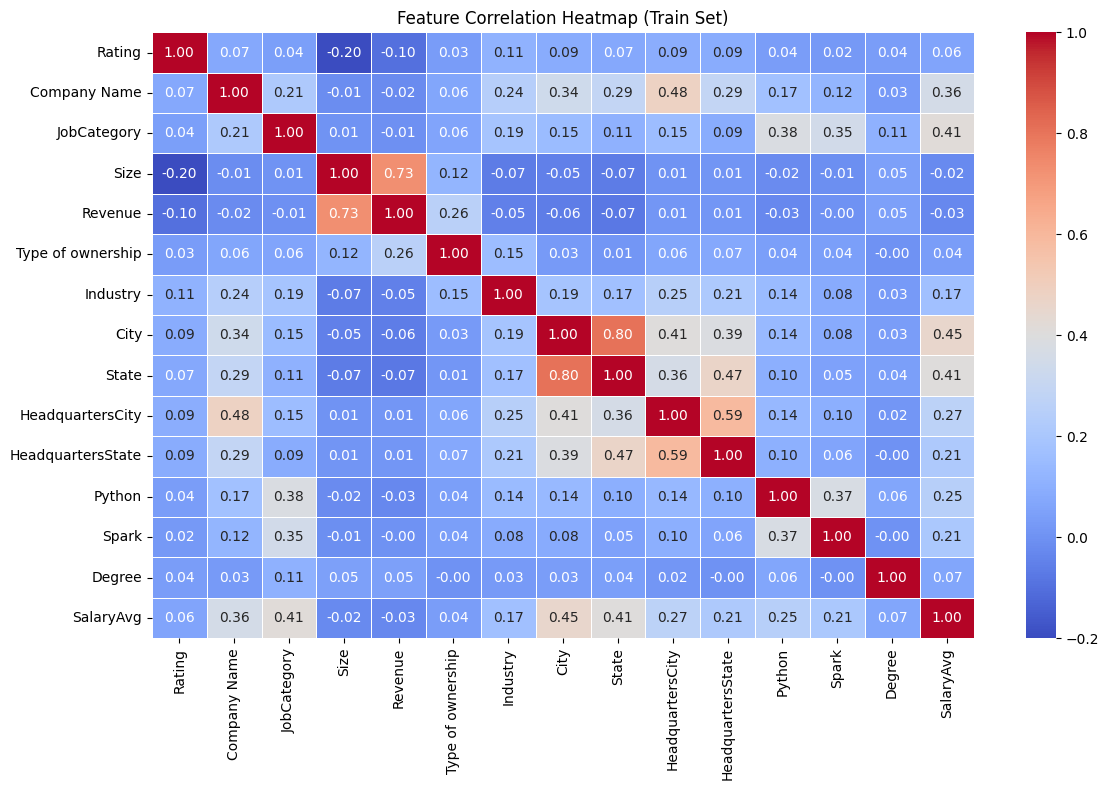

In [130]:
train_data_for_corr = X_train.copy()

# Add the target variable (unscaled y_train is fine for Pearson correlation)
train_data_for_corr['SalaryAvg'] = y_train.values

# Calculate correlation matrix
correlation_matrix = train_data_for_corr.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f" # Limit to 2 decimal places
)
plt.title('Feature Correlation Heatmap (Train Set)')
plt.tight_layout()
plt.show()

In [131]:
xgb_model = XGBRegressor(n_estimators=235, learning_rate=0.03, max_depth=10, subsample=0.7, colsample_bytree = 0.6, random_state=42)
xgb_model.fit(X_train, y_train_scaled)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=235,
             n_jobs=None, num_parallel_tree=None, ...)

In [132]:
# Predict on the test set
y_pred_scaled = xgb_model.predict(X_test)

# Inverse transform to get predictions in original salary values
y_pred_xgb = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# mse = mean_squared_error(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae}, R2: {r2}")

MAE: 16550.452605654762, R2: 0.4204077947667719


In [133]:
mape = mean_absolute_percentage_error(y_test, y_pred_xgb)
print(f"MAPE: {mape * 100:.2f}%")

MAPE: 21.98%


<Figure size 1000x600 with 0 Axes>

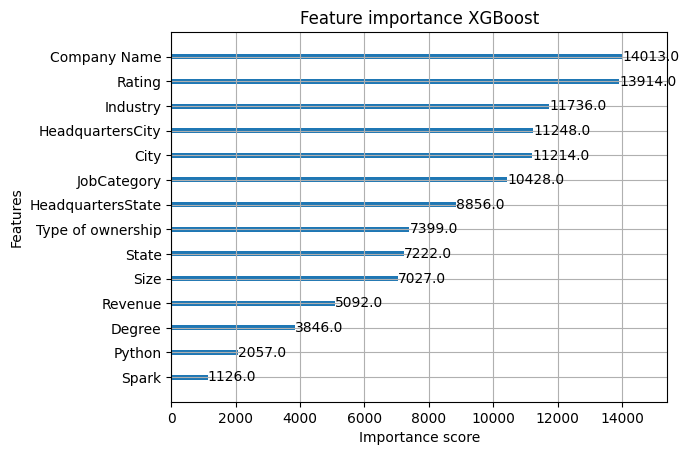

In [134]:
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=20, importance_type='weight')
plt.title("Feature importance XGBoost")
plt.show()


In [135]:
indices = range(5)
multiple_samples = X_test.iloc[indices]
predicted_values_scaled_sample = xgb_model.predict(multiple_samples)
# Decode predictions
predicted_values = scaler_y.inverse_transform(predicted_values_scaled_sample.reshape(-1, 1)).flatten()

# Get true values
true_values_sample = y_test.iloc[indices].values

for i, (pred, true) in enumerate(zip(predicted_values, true_values_sample)):
    print(f"Sample {i}: Predicted Value = {pred}, True Value = {true}")


Sample 0: Predicted Value = 93888.484375, True Value = 99000.0
Sample 1: Predicted Value = 72133.1171875, True Value = 64500.0
Sample 2: Predicted Value = 89726.2890625, True Value = 66000.0
Sample 3: Predicted Value = 88750.5, True Value = 92500.0
Sample 4: Predicted Value = 129287.796875, True Value = 158000.0
